# Pengujian Performa dan Akurasi Algoritma — NutriFit

Notebook ini menguji algoritma yang **benar-benar dijalankan aplikasi**, bukan algoritma
yang mirip dengannya.

Perbedaannya penting. Aplikasi tidak mengklaster isi CSV apa adanya: ia menyaring makanan
(hanya hidangan siap santap bergambar valid), membuang baris latihan yang kolomnya kosong,
menormalkan level pengalaman, dan menskalakan fitur dengan `MinMaxScaler`. Menguji CSV mentah
akan menghasilkan angka yang tidak bisa direproduksi dari aplikasi mana pun.

Karena itu notebook ini **mengimpor fungsi persiapan data milik aplikasi** dan mengukur
keluarannya:

| Bagian | Algoritma | Data | Penetapan K | Uji performa |
|---|---|---|---|---|
| 0 | Semua | Ketiga dataset | — | Hopkins Statistic (kelayakan diklaster) |
| 1 | K-Means | Menu makanan (setelah `prepare_foods`) | Struktural (dibandingkan Metode Siku) | **Calinski-Harabasz Index** + **Silhouette Coefficient** + Inertia |
| 2 | K-Modes | Program latihan (setelah `prepare_exercises`) | Metode Siku atas Hamming Cost | Rasio Hamming + Chi-Square |
| 3 | K-Prototypes | Profil anggota (setelah `clean_members`) | Metode Siku atas Cost Function | **Silhouette Score dengan Gower Distance** |
| 4 | Semua | Ketiga algoritma | — | Uji stabilitas 50 eksekusi |
| 5 | CBF + TF-IDF | Menu makanan dan program latihan | — | **MAP + NDCG** (metrik peringkat Top-N) |
| 6 | Pengujian fungsional | Seluruh aturan bisnis | — | skrip `tests/` |

## Dua aturan yang dipegang notebook ini

**1. K ditetapkan Metode Siku (Elbow Method), dan hanya itu.** Untuk tiap algoritma, biaya
terbaik pada K = 2..10 dihitung, lalu titik sikunya dicari secara terukur — sebagai titik
kurva yang paling jauh dari garis lurus penghubung kedua ujungnya — bukan ditaksir dengan
mata dari grafik. Fungsi penetapnya (`R.search_member_clusters`, `R.search_exercise_clusters`)
adalah fungsi yang dipanggil aplikasi saat berjalan, sehingga K di notebook dan K di aplikasi
tidak mungkin berbeda.

**2. Pemilih K dan penilai mutu dipisahkan.** Metrik mutu — Calinski-Harabasz,
Silhouette-Gower, Rasio Hamming — dihitung **sesudah** K ditetapkan, dan tidak pernah ikut
memilihnya. Metrik yang sekaligus menjadi pemilih K selalu terlihat bagus, karena K-nya
memang dipilih supaya metrik itu setinggi mungkin; angka semacam itu tidak membuktikan apa
pun. Dengan pemisahan ini, nilai yang dilaporkan adalah penilaian terhadap keputusan yang
sudah diambil, bukan pujian yang diatur sendiri.

## 0. Persiapan

In [1]:
# Notebook ini TIDAK butuh paket kmodes. K-Modes dan K-Prototypes yang diuji adalah
# implementasi milik aplikasi sendiri (src/recommender.py), bukan library pihak ketiga --
# menguji library berarti menguji kode yang tidak pernah dijalankan produk.
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():          # kalau notebook dibuka dari folder induk
    ROOT = ROOT / "NutriFit"
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import chi2_contingency

from src import recommender as R
from src import clustering_metrics as CM
from src import ranking_metrics as RM

plt.rcParams["figure.figsize"] = (7, 4)
pd.set_option("display.width", 120)
print("Library siap. Modul aplikasi diimpor dari:", ROOT)

Library siap. Modul aplikasi diimpor dari: c:\Kuliah\Semester 8\Tugas Akhir\Coding\NutriFit


### 0.1 Memuat data lewat pipeline aplikasi

`prepare_foods`, `prepare_exercises`, dan `clean_members` adalah fungsi yang dipanggil
aplikasi saat start. Memanggilnya di sini berarti seluruh angka di bawah dihitung pada
data yang persis sama dengan yang dipakai pengguna.

**Sumber datanya juga harus sama, bukan hanya fungsinya.** Aplikasi membaca tabel MySQL,
sedangkan berkas CSV di `data/` hanya benih untuk mengisi tabel itu. Keduanya bisa
menyimpang tanpa memunculkan galat apa pun — dan pernah benar-benar menyimpang: nama pada
39 baris berbeda, membuat notebook menghitung 846 menu sementara pengguna hanya menerima
816. Karena itu di sini data diambil lewat `R.load_dataset_tables()`, jalur yang sama
dengan aplikasi, dan selisihnya terhadap CSV diperiksa terang-terangan.

In [2]:
DATA = ROOT / "data"

# Sumber utama: tabel yang benar-benar dibaca aplikasi.
try:
    anggota_mentah, makanan_mentah, latihan_mentah = R.load_dataset_tables()
    SUMBER = "MySQL (sumber yang dipakai aplikasi)"
except Exception as galat:            # mis. dijalankan di Colab tanpa basis data
    print(f"!! Basis data tidak bisa dihubungi ({type(galat).__name__}), memakai CSV benih.")
    print("!! Angka di bawah menggambarkan CSV, BELUM TENTU sama dengan yang diterima pengguna.")
    makanan_mentah = pd.read_csv(DATA / "food_nutrition.csv")
    latihan_mentah = pd.read_csv(DATA / "training_program.csv")
    anggota_mentah = pd.read_csv(DATA / "gym_members.csv")
    SUMBER = "CSV benih (basis data tidak tersedia)"

print("Sumber data:", SUMBER)

foods     = R.prepare_foods(makanan_mentah)
exercises = R.prepare_exercises(latihan_mentah)
members   = R.clean_members(anggota_mentah)

ringkas = pd.DataFrame([
    {"Dataset": "Menu makanan",   "Baris CSV": len(makanan_mentah), "Dipakai aplikasi": len(foods)},
    {"Dataset": "Program latihan","Baris CSV": len(latihan_mentah), "Dipakai aplikasi": len(exercises)},
    {"Dataset": "Profil anggota", "Baris CSV": len(anggota_mentah), "Dipakai aplikasi": len(members)},
])
ringkas["Tersaring"] = ringkas["Baris CSV"] - ringkas["Dipakai aplikasi"]
print("Baris yang benar-benar diklaster aplikasi:\n")
display(ringkas)
print(
    "\nMakanan tersaring  : bukan hidangan siap santap, gambar tidak bisa ditampilkan,"
    "\n                     kalori <= 0, atau bahan yang dikecualikan."
    "\nLatihan tersaring  : ada kolom wajib yang kosong (Title/Desc/Type/BodyPart/Equipment/Level)."
)

Sumber data: MySQL (sumber yang dipakai aplikasi)


Baris yang benar-benar diklaster aplikasi:



,Dataset,Baris CSV,Dipakai aplikasi,Tersaring
0,Menu makanan,1587,814,773
1,Program latihan,2918,1359,1559
2,Profil anggota,973,973,0



Makanan tersaring  : bukan hidangan siap santap, gambar tidak bisa ditampilkan,
                     kalori <= 0, atau bahan yang dikecualikan.
Latihan tersaring  : ada kolom wajib yang kosong (Title/Desc/Type/BodyPart/Equipment/Level).


### 0.2 Penjaga sinkronisasi — apakah CSV benih masih sama dengan basis data?

Berkas CSV di `data/` mengisi tabel MySQL lewat `schema_data/import_csv_to_db.py`. Kalau
CSV diubah tanpa importer dijalankan ulang — atau sebaliknya — keduanya menyimpang **tanpa
satu pun galat muncul**. Notebook akan tetap jalan dan tetap mengeluarkan angka; angkanya
saja yang menggambarkan dataset yang salah.

Pemeriksaan di bawah membuat penyimpangan itu terlihat seketika.

In [3]:
def bandingkan_sumber(nama, berkas, tabel, kunci=None):
    try:
        csv_df = pd.read_csv(DATA / berkas)
    except Exception as galat:
        return {"Dataset": nama, "Status": f"CSV tak terbaca ({type(galat).__name__})",
                "Baris CSV": "-", "Baris DB": len(tabel), "Nilai berbeda": "-"}

    catatan = {"Dataset": nama, "Baris CSV": len(csv_df), "Baris DB": len(tabel)}
    if len(csv_df) != len(tabel):
        catatan.update(Status="JUMLAH BARIS BEDA", **{"Nilai berbeda": "-"})
        return catatan

    a, b = csv_df, tabel
    if kunci and kunci in csv_df.columns and kunci in tabel.columns:
        a = csv_df.set_index(kunci).sort_index()
        b = tabel.set_index(kunci).sort_index()

    beda = 0
    for kolom in [c for c in a.columns if c in b.columns]:
        x, y = a[kolom], b[kolom]
        if pd.api.types.is_numeric_dtype(x) and pd.api.types.is_numeric_dtype(y):
            beda += int((~np.isclose(x.fillna(-9e9), y.fillna(-9e9))).sum())
        else:
            beda += int((x.fillna("").astype(str).str.strip()
                         != y.fillna("").astype(str).str.strip()).sum())
    catatan["Nilai berbeda"] = beda
    catatan["Status"] = "sinkron" if beda == 0 else "TIDAK SINKRON"
    return catatan


sinkron = pd.DataFrame([
    bandingkan_sumber("Menu makanan",   "food_nutrition.csv",  makanan_mentah, kunci="id"),
    bandingkan_sumber("Program latihan","training_program.csv", latihan_mentah),
    bandingkan_sumber("Profil anggota", "gym_members.csv",      anggota_mentah),
])[["Dataset", "Baris CSV", "Baris DB", "Nilai berbeda", "Status"]]
display(sinkron)

if (sinkron["Status"] == "sinkron").all():
    print("CSV benih dan basis data identik -- angka di notebook = angka yang diterima pengguna.")
else:
    print("!! Ada yang tidak sinkron. Jalankan: python schema_data/import_csv_to_db.py")
    print("!! Sebelum itu, angka di bawah TIDAK menggambarkan data yang dipakai aplikasi.")

,Dataset,Baris CSV,Baris DB,Nilai berbeda,Status
0,Menu makanan,1587,1587,0,sinkron
1,Program latihan,2918,2918,0,sinkron
2,Profil anggota,973,973,0,sinkron


CSV benih dan basis data identik -- angka di notebook = angka yang diterima pengguna.


### 0.3 Hopkins Statistic — apakah datanya memang layak diklasterkan?

Sebelum menilai *seberapa bagus* klasternya, ada pertanyaan yang lebih mendasar:
**apakah data ini punya struktur kelompok sama sekali?**

Ini penting karena Silhouette, Cost, dan Inertia **selalu menghasilkan angka**, bahkan pada
data acak murni. Algoritma klasterisasi akan tetap membagi awan titik yang benar-benar acak
menjadi K bagian dan melaporkan nilai yang terlihat wajar. Tanpa uji kelayakan, kita tidak
bisa membedakan "klaster yang bermakna" dari "potongan sembarang".

Hopkins Statistic membandingkan dua hal:

$$H = rac{\sum_{i=1}^{m} u_i}{\sum_{i=1}^{m} u_i + \sum_{i=1}^{m} w_i}$$

- $w_i$ — jarak titik **asli** ke tetangga terdekatnya
- $u_i$ — jarak titik **buatan** (acak seragam pada rentang data) ke titik asli terdekat

| Nilai H | Arti |
|---|---|
| mendekati **1** | Data sangat berkelompok, sangat layak diklasterkan |
| sekitar **0,5** | Sebaran tidak berbeda dari acak; klaster kurang bermakna |
| mendekati **0** | Data tersebar terlalu merata (anti-kelompok) |

Jaraknya disesuaikan tipe data: Euclid untuk numerik, **Hamming** untuk kategorikal, dan
jarak campuran untuk K-Prototypes — sama dengan jarak yang dipakai masing-masing algoritma.

,Dataset,Algoritma,Jarak,Hopkins,Interpretasi
0,Menu makanan,K-Means,Euclid,0.9324,Sangat layak diklasterkan (struktur kelompok k...
1,Program latihan,K-Modes,Hamming,0.9721,Sangat layak diklasterkan (struktur kelompok k...
2,Profil anggota,K-Prototypes,Campuran,0.9718,Sangat layak diklasterkan (struktur kelompok k...


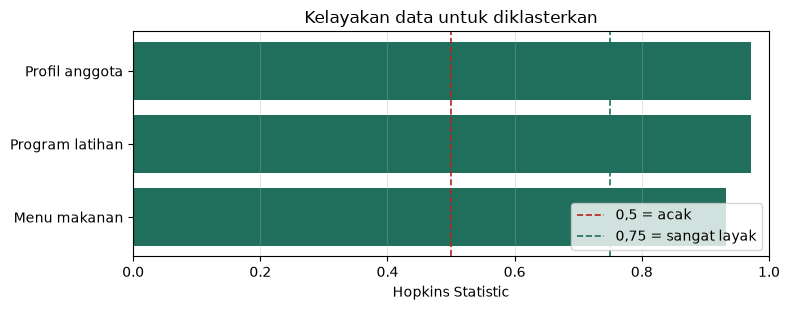

,Dataset,Min,Maks,Rentang
0,Menu makanan,0.9256,0.9508,0.0251
1,Program latihan,0.9312,0.9817,0.0505
2,Profil anggota,0.9427,0.9807,0.0380


Rentang sempit = nilai Hopkins tidak bergantung pada sampel yang kebetulan terambil.


In [4]:
KOL_NUM = ["Age", "Weight (kg)", "Height (m)", "BMI"]
KOL_KAT = ["Gender", "Activity_Level", "Experience_Label", "Fitness_Goal"]
FITUR_MAKANAN = ["calories", "proteins", "fat", "carbohydrate"]

X_makanan = MinMaxScaler().fit_transform(foods[FITUR_MAKANAN])
kategori_latihan = R.exercise_cluster_features(exercises)
nilai_latihan = kategori_latihan.astype(str).to_numpy()
numerik, kategorikal, scaler = R.member_feature_matrices(members, KOL_NUM, KOL_KAT)

h_makanan = CM.hopkins_numeric(X_makanan, random_state=42)
h_latihan = CM.hopkins_categorical(nilai_latihan, random_state=42)
h_anggota = CM.hopkins_mixed(numerik, kategorikal, random_state=42)

tabel_hopkins = pd.DataFrame([
    {"Dataset": "Menu makanan",    "Algoritma": "K-Means",      "Jarak": "Euclid",
     "Hopkins": round(h_makanan, 4), "Interpretasi": CM.interpret_hopkins(h_makanan)},
    {"Dataset": "Program latihan", "Algoritma": "K-Modes",      "Jarak": "Hamming",
     "Hopkins": round(h_latihan, 4), "Interpretasi": CM.interpret_hopkins(h_latihan)},
    {"Dataset": "Profil anggota",  "Algoritma": "K-Prototypes", "Jarak": "Campuran",
     "Hopkins": round(h_anggota, 4), "Interpretasi": CM.interpret_hopkins(h_anggota)},
])
display(tabel_hopkins)

fig, ax = plt.subplots(figsize=(8, 3.2))
warna = ["#1f6f5c" if v >= 0.6 else "#b3261e" for v in tabel_hopkins["Hopkins"]]
ax.barh(tabel_hopkins["Dataset"], tabel_hopkins["Hopkins"], color=warna)
ax.axvline(0.5, color="#b3261e", linestyle="--", linewidth=1.2, label="0,5 = acak")
ax.axvline(0.75, color="#1f6f5c", linestyle="--", linewidth=1.2, label="0,75 = sangat layak")
ax.set(xlim=(0, 1), xlabel="Hopkins Statistic", title="Kelayakan data untuk diklasterkan")
ax.legend(loc="lower right"); ax.grid(alpha=.3, axis="x")
plt.tight_layout(); plt.show()

# Hopkins sendiri memakai pengambilan sampel acak, jadi nilainya diperiksa pada
# beberapa seed -- kalau angkanya melompat-lompat, kesimpulannya tidak bisa dipakai.
sebaran = {
    "Menu makanan":    [CM.hopkins_numeric(X_makanan, random_state=s) for s in range(10)],
    "Program latihan": [CM.hopkins_categorical(nilai_latihan, random_state=s) for s in range(10)],
    "Profil anggota":  [CM.hopkins_mixed(numerik, kategorikal, random_state=s) for s in range(10)],
}
display(pd.DataFrame([
    {"Dataset": nama, "Min": round(min(v), 4), "Maks": round(max(v), 4),
     "Rentang": round(max(v) - min(v), 4)}
    for nama, v in sebaran.items()
]))
print("Rentang sempit = nilai Hopkins tidak bergantung pada sampel yang kebetulan terambil.")

---
## 1. K-Means — Menu Makanan (data numerik)

Fitur: `calories`, `proteins`, `fat`, `carbohydrate`, diskalakan dengan **MinMaxScaler**
— penskalaan yang sama dengan `assign_food_clusters` di aplikasi.

### 1.1 Metode Siku (Elbow Method) atas WCSS

$$WCSS(K) = \sum_{k=1}^{K}\sum_{x_i \in C_k} \lVert x_i - \mu_k \rVert^2$$

WCSS **selalu** turun saat K bertambah — pada K = jumlah data ia mencapai nol. Karena itu
"WCSS terkecil" bukan kriteria; yang dicari adalah **titik siku**, yaitu K terakhir yang
penambahannya masih memberi penurunan besar.

Sikunya tidak ditaksir dengan mata. Kedua sumbu dinormalkan ke 0..1, sebuah garis lurus
ditarik dari titik K terkecil ke titik K terbesar, lalu **jarak tiap titik kurva ke garis
itu** dihitung. Titik terjauh adalah tikungan paling tajam — itulah sikunya. Cara ini
memberi angka yang sama setiap kali dijalankan siapa pun yang membacanya
(`R.elbow_cluster_count`).

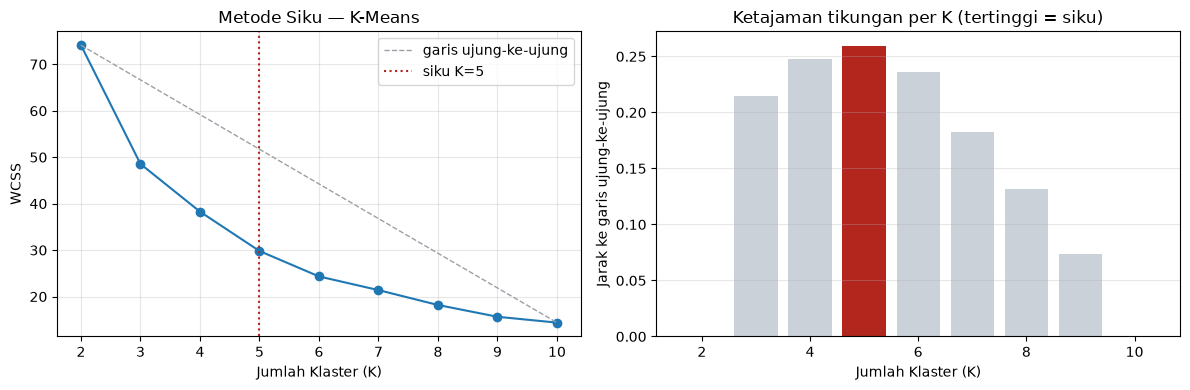

,K,WCSS,Penurunan,Jarak ke garis,Titik siku
0,2,74.1088,NaN,0.0000,
1,3,48.5466,25.5623,0.2143,
2,4,38.2798,10.2667,0.2475,
3,5,29.8071,8.4728,0.2594,<-- K dipilih
4,6,24.3343,5.4728,0.2358,
5,7,21.3918,2.9425,0.1823,
6,8,18.1892,3.2026,0.1318,
7,9,15.6521,2.5371,0.0735,
8,10,14.3921,1.2599,0.0000,


Titik siku kurva WCSS   : K = 5
K yang dipakai aplikasi : K = 3   (alasan struktural -- lihat 1.2)


In [5]:
K_RANGE = list(R.CLUSTER_SEARCH_RANGE)          # rentang yang sama dengan aplikasi

wcss = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    km.fit(X_makanan)
    wcss.append(float(km.inertia_))

K_SIKU_MAKANAN = R.elbow_cluster_count(K_RANGE, wcss)
jarak_siku = R.elbow_distances(K_RANGE, wcss)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_RANGE, wcss, marker="o")
ax1.plot([K_RANGE[0], K_RANGE[-1]], [wcss[0], wcss[-1]], "--", color="#9aa0a6",
         linewidth=1, label="garis ujung-ke-ujung")
ax1.axvline(K_SIKU_MAKANAN, color="#b3261e", linestyle=":", label=f"siku K={K_SIKU_MAKANAN}")
ax1.set(xlabel="Jumlah Klaster (K)", ylabel="WCSS", title="Metode Siku — K-Means")
ax1.legend(); ax1.grid(alpha=.3)

ax2.bar(K_RANGE, jarak_siku, color=["#b3261e" if k == K_SIKU_MAKANAN else "#cbd1d9" for k in K_RANGE])
ax2.set(xlabel="Jumlah Klaster (K)", ylabel="Jarak ke garis ujung-ke-ujung",
        title="Ketajaman tikungan per K (tertinggi = siku)")
ax2.grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()

display(R.elbow_table(K_RANGE, wcss, cost_label="WCSS"))
print(f"Titik siku kurva WCSS   : K = {K_SIKU_MAKANAN}")
print(f"K yang dipakai aplikasi : K = {R.FOOD_CLUSTER_COUNT}   (alasan struktural -- lihat 1.2)")

### 1.2 Uji performa: Calinski-Harabasz Index dan Silhouette Coefficient

Setelah K ditetapkan, mutunya diuji. Inertia tidak bisa dipakai untuk itu — ia selalu turun
saat K bertambah, jadi ia hanya menggambarkan kerapatan, bukan pemisahan. Dua metrik lain
yang dipakai sengaja melihat hal yang berbeda.

**Calinski-Harabasz Index** (*Variance Ratio Criterion*) menilai seluruh struktur sekaligus
lewat satu rasio ragam:

$$CH = \frac{\mathrm{tr}(B_K)}{\mathrm{tr}(W_K)} \times \frac{N - K}{K - 1}$$

- $\mathrm{tr}(B_K)$ — sebaran **antar** klaster (pusat klaster terhadap pusat data)
- $\mathrm{tr}(W_K)$ — sebaran **di dalam** klaster (anggota terhadap pusat klasternya)

Makin besar makin baik. Nilainya tidak punya batas atas, jadi ia bermakna sebagai
perbandingan antar-K pada dataset yang sama, bukan sebagai angka mutlak.

**Silhouette Coefficient** memeriksa **tiap menu satu per satu** terhadap tetangganya, lalu
dirata-ratakan:

$$S(i) = \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}}$$

- $a(i)$ — rata-rata jarak menu $i$ ke sesama anggota klasternya
- $b(i)$ — rata-rata jarak menu $i$ ke anggota klaster **tetangga terdekat**

Nilainya terbatas −1 sampai 1: mendekati 1 berarti menu itu jauh lebih dekat ke kelompoknya
sendiri daripada ke kelompok lain, sekitar 0 berarti ia berada di perbatasan, dan negatif
berarti ia sebenarnya lebih cocok di klaster sebelah.

**Kenapa dua-duanya dipakai.** CH bisa tinggi karena struktur besarnya rapi walaupun banyak
menu duduk di perbatasan; Silhouette menangkap justru menu-menu perbatasan itu. Ketika
keduanya menunjuk K yang berbeda — dan di bab 1.3 memang begitu — perbedaannya sendiri yang
informatif, bukan gangguan yang perlu disembunyikan.

Keduanya adalah **penilai, bukan pemilih**. Untuk K-Means makanan hal itu bahkan tidak mungkin
dilanggar: K-nya ditetapkan kebutuhan struktural aplikasi, jadi tidak ada satu pun angka di
bawah yang ikut menentukannya.

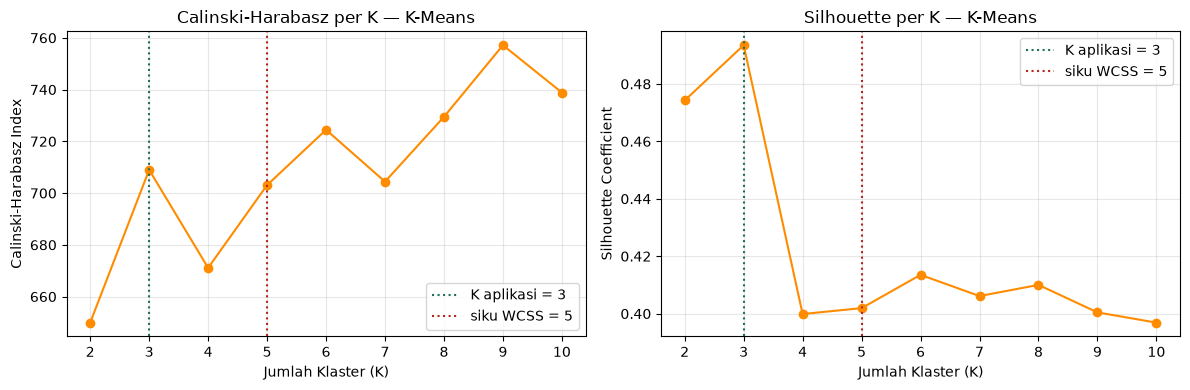

,K,WCSS,Calinski-Harabasz,Silhouette
0,2,74.109,649.9,0.4743
1,3,48.547,709.0,0.4935
2,4,38.280,671.1,0.3999
3,5,29.807,703.1,0.4019
4,6,24.334,724.5,0.4135
5,7,21.392,704.4,0.4061
6,8,18.189,729.5,0.4100
7,9,15.652,757.2,0.4004
8,10,14.392,738.9,0.3969


K final                 : 3
Silhouette Coefficient  : 0.4935   (-1 s.d. 1; makin besar makin terpisah)
Calinski-Harabasz Index : 708.9929   (makin besar makin terpisah)
Inertia (WCSS)          : 48.5466   (mendekati 0 = anggota rapat ke pusatnya)

Sama dengan yang dipakai aplikasi : True


,calories,proteins,fat,carbohydrate,Jumlah,Peran
Klaster,,,,,,
A,363.2,5.8,10.7,61.5,195,Tinggi karbohidrat
B,374.9,26.0,25.2,11.6,121,Tinggi protein
C,116.7,5.6,3.2,16.6,498,Rendah kalori


In [6]:
kmeans_final = KMeans(n_clusters=R.FOOD_CLUSTER_COUNT, init="k-means++", n_init=10, random_state=42)
label_kmeans = kmeans_final.fit_predict(X_makanan)

inertia_kmeans = float(kmeans_final.inertia_)
ch_kmeans = float(calinski_harabasz_score(X_makanan, label_kmeans))
sil_kmeans = float(silhouette_score(X_makanan, label_kmeans))

# Kedua metrik pada seluruh rentang K -- sebagai KETERANGAN, bukan pemilih K.
# K sudah ditetapkan lebih dulu; kurva ini hanya menunjukkan di mana K itu berdiri.
ch_per_k, sil_per_k_makanan = [], []
for k in K_RANGE:
    label_k = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42).fit_predict(X_makanan)
    ch_per_k.append(float(calinski_harabasz_score(X_makanan, label_k)))
    sil_per_k_makanan.append(float(silhouette_score(X_makanan, label_k)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for ax, nilai, judul, sumbu_y in [
    (ax1, ch_per_k, "Calinski-Harabasz per K", "Calinski-Harabasz Index"),
    (ax2, sil_per_k_makanan, "Silhouette per K", "Silhouette Coefficient"),
]:
    ax.plot(K_RANGE, nilai, marker="o", color="darkorange")
    ax.axvline(R.FOOD_CLUSTER_COUNT, color="#1f6f5c", linestyle=":",
               label=f"K aplikasi = {R.FOOD_CLUSTER_COUNT}")
    ax.axvline(K_SIKU_MAKANAN, color="#b3261e", linestyle=":", label=f"siku WCSS = {K_SIKU_MAKANAN}")
    ax.set(xlabel="Jumlah Klaster (K)", ylabel=sumbu_y, title=f"{judul} — K-Means")
    ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

display(pd.DataFrame({"K": K_RANGE,
                      "WCSS": np.round(wcss, 3),
                      "Calinski-Harabasz": np.round(ch_per_k, 1),
                      "Silhouette": np.round(sil_per_k_makanan, 4)}))

print(f"K final                 : {R.FOOD_CLUSTER_COUNT}")
print(f"Silhouette Coefficient  : {sil_kmeans:.4f}   (-1 s.d. 1; makin besar makin terpisah)")
print(f"Calinski-Harabasz Index : {ch_kmeans:,.4f}   (makin besar makin terpisah)")
print(f"Inertia (WCSS)          : {inertia_kmeans:.4f}   (mendekati 0 = anggota rapat ke pusatnya)")

# Angka yang sama dengan yang ditampilkan halaman Admin aplikasi.
kinerja_kmeans = R.kmeans_food_performance(foods)
print("\nSama dengan yang dipakai aplikasi :",
      np.isclose(kinerja_kmeans["score"], round(ch_kmeans, 3))
      and np.isclose(kinerja_kmeans["extra_scores"]["Silhouette"], round(sil_kmeans, 3)))

profil = foods.assign(Klaster=foods["Food_Cluster"]).groupby("Klaster")[FITUR_MAKANAN].mean().round(1)
profil["Jumlah"] = foods.groupby("Food_Cluster").size()
profil["Peran"] = ["Tinggi karbohidrat", "Tinggi protein", "Rendah kalori"]
display(profil)

### 1.3 Penjelasan pemilihan K = 3

Bagian ini menjawab pertanyaan yang paling wajar diajukan terhadap bab ini: **kenapa K = 3,
padahal Metode Siku menunjuk angka lain?**

#### Tiga kriteria, tiga jawaban berbeda

Ketiganya dihitung pada data yang sama dan tidak ada yang salah hitung — ketiganya memang
menanyakan hal yang berbeda:

| Kriteria | Pertanyaannya | Jawabannya |
|---|---|---|
| Silhouette | Seberapa jauh tiap menu dari klaster tetangganya? | **K = 3** |
| Metode Siku (WCSS) | Sampai kapan tambahan klaster masih memangkas ragam? | **K = 5** |
| Calinski-Harabasz | Seberapa besar rasio ragam antar terhadap ragam dalam? | **K = 9** |

Perbedaannya bisa dijelaskan. Data gizi adalah **awan yang menyambung** — tidak ada jurang
alami antara "tinggi protein" dan "tinggi karbohidrat", yang ada peralihan bertahap. Pada data
semacam itu Silhouette cenderung menyukai K kecil, karena memecah lebih banyak hanya membuat
klaster bertetangga makin berdempet. Metode Siku tidak peduli pada tetangga; ia hanya melihat
penurunan ragam, yang masih terbayar sampai K = 5. Calinski-Harabasz adalah rasio yang
disesuaikan derajat bebas $(N-K)/(K-1)$, dan pada awan yang menyambung ia bisa terus naik.

Kalau K diserahkan pada metrik, jawabannya tergantung metrik mana yang kebetulan dipilih —
dan itu persis alasan notebook ini memisahkan pemilih dari penilai.

#### Yang menetapkan K = 3 adalah kebutuhan struktural

`MEAL_TEMPLATE` menyusun empat slot makan dari **tepat tiga peran gizi**:

| Slot | Peran yang diambil |
|---|---|
| Sarapan | A, B |
| Makan Siang | A, B, C |
| Camilan | C |
| Makan Malam | B, C |

dengan A = tinggi karbohidrat, B = tinggi protein, C = rendah kalori. Pemetaannya dilakukan
`assign_food_clusters` berdasarkan watak gizi tiap klaster, bukan berdasarkan nomor klaster
yang diberikan K-Means — jadi labelnya tetap bermakna walau K-Means mengacak urutannya.

Dengan K lain, pemetaan ini kehilangan arti: **tidak ada peran gizi keempat dan kelima yang
bisa diisi template makan**. Sel 1.4 di bawah menunjukkan bahwa K = 5 pun bukan pemecahan
halus dari A/B/C — ia memotong menyilang, sehingga mengadopsinya berarti merancang ulang
seluruh template, bukan menambah dua huruf.

Jadi K = 3 **bukan** kesimpulan dari sebuah metrik. Ia keputusan rancangan produk, dan bab ini
menyebutnya begitu, bukan mengarang pembenaran statistik untuknya.

#### Kebetulan yang tidak boleh dijadikan bukti

K = 3 memang bertepatan dengan puncak Silhouette. Godaannya adalah menuliskan itu sebagai
"keputusan struktural yang terbukti optimal secara empiris" — dan versi sebelumnya dari
notebook ini memang begitu.

Klaim itu tidak sah, karena Silhouette waktu itu **sekaligus dipakai memilih K**. Sebuah
metrik yang memilih K akan selalu terlihat membenarkan K yang dipilihnya; kesepakatan itu
sifatnya melingkar. Buktinya sederhana: ganti pemilihnya jadi Metode Siku atau Calinski-
Harabasz, dan "kesepakatan" itu langsung hilang. Yang bertahan hanyalah alasan struktural —
dan alasan itu tidak bergantung pada metrik mana pun.

#### Harga yang dibayar, disebut terus terang

K = 3 punya konsekuensi yang terukur, dan sel 1.4 menampilkannya apa adanya:

1. **Klaster C menjadi keranjang serba ada** — 61% dataset, dengan rentang kalori puluhan kali
   lipat di dalam satu label "rendah kalori".
2. **Sebagian label meleset secara gizi** — beberapa menu berlemak sangat tinggi mendarat di
   peran B ("tinggi protein") karena lemaknya menarik mereka ke pusat klaster itu.
3. **Ragam yang tidak terjelaskan lebih besar** daripada di K = 5.
4. **Kolam peran B sempit** (15% dataset) padahal dipakai dua slot.

Konsekuensi ini tidak membatalkan K = 3; ia menunjukkan bahwa **label klaster adalah petunjuk
kasar**, dan mutu rekomendasi yang diterima pengguna ditopang lapisan lain yang memang sudah
ada: saringan `Is_Snack`, pencocokan kategori bahan utama, dan Volumetric Sanity Check. Untuk
bab saran pengembangan, dua perbaikan yang paling terukur adalah memecah C menjadi dua peran
dan menambahkan pengaman kadar lemak pada peran B.

### 1.4 Bukti angka untuk pembahasan di atas

In [7]:
# --- Tiga kriteria, tiga jawaban -------------------------------------------- #
putusan = pd.DataFrame([
    {"Kriteria": "Silhouette Coefficient", "K terpilih": K_RANGE[int(np.argmax(sil_per_k_makanan))],
     "Nilai di K itu": round(max(sil_per_k_makanan), 4), "Perannya": "penilai"},
    {"Kriteria": "Metode Siku (WCSS)", "K terpilih": K_SIKU_MAKANAN,
     "Nilai di K itu": round(float(max(R.elbow_distances(K_RANGE, wcss))), 4), "Perannya": "penetap K (dibandingkan)"},
    {"Kriteria": "Calinski-Harabasz", "K terpilih": K_RANGE[int(np.argmax(ch_per_k))],
     "Nilai di K itu": round(max(ch_per_k), 1), "Perannya": "penilai"},
    {"Kriteria": "Kebutuhan struktural MEAL_TEMPLATE", "K terpilih": R.FOOD_CLUSTER_COUNT,
     "Nilai di K itu": "-", "Perannya": "PENETAP K yang dipakai"},
])
display(putusan)

# --- Konsekuensi 1: keragaman di dalam tiap peran gizi ----------------------- #
kel = foods.groupby("Food_Cluster")
keragaman = pd.DataFrame({
    "Jumlah": kel.size(),
    "% dataset": (kel.size() / len(foods) * 100).round(1),
    "Kalori rata-rata": kel["calories"].mean().round(1),
    "Simpangan baku": kel["calories"].std().round(1),
    "Kalori min": kel["calories"].min().round(1),
    "Kalori maks": kel["calories"].max().round(1),
})
keragaman["Rentang (maks/min)"] = (
    keragaman["Kalori maks"] / keragaman["Kalori min"].replace(0, np.nan)
).round(1)
print("Keragaman di dalam tiap peran gizi -- makin lebar, makin longgar arti labelnya:")
display(keragaman)

# --- Konsekuensi 2: label yang meleset secara gizi --------------------------- #
print("Menu paling berlemak yang tetap berlabel B (peran 'tinggi protein'):")
display(foods[foods["Food_Cluster"] == "B"].nlargest(5, "fat")[["name"] + FITUR_MAKANAN]
        .reset_index(drop=True))
print("Menu berkalori tertinggi yang tetap berlabel C (peran 'rendah kalori'):")
display(foods[foods["Food_Cluster"] == "C"].nlargest(5, "calories")[["name"] + FITUR_MAKANAN]
        .reset_index(drop=True))

# --- Konsekuensi 3: K=5 memotong menyilang, bukan memecah halus -------------- #
label_lima = KMeans(n_clusters=5, init="k-means++", n_init=10, random_state=42).fit_predict(X_makanan)
silang = pd.crosstab(pd.Series(label_lima, index=foods.index, name="Klaster K=5"),
                     foods["Food_Cluster"])
print("Kalau K=5 dipakai, begini ia jatuh ke peran gizi yang sekarang:")
display(silang)
utuh = int((silang > 0).sum(axis=1).eq(1).sum())
print(f"Hanya {utuh} dari 5 klaster yang jatuh utuh ke satu peran; sisanya terbelah.")
print("Karena itu K=5 tidak bisa dipakai dengan menambah dua huruf pada MEAL_TEMPLATE --")
print("seluruh pemetaan slot harus dirancang ulang.")

# --- Konsekuensi 4: mutu slot ditopang saringan lain, bukan oleh klaster ----- #
anggota_c = foods[foods["Food_Cluster"] == "C"]
lolos_camilan = int(anggota_c["Is_Snack"].sum())
print(f"\nSlot Camilan hanya boleh diisi peran C: {len(anggota_c)} anggota,")
print(f"tetapi hanya {lolos_camilan} yang lolos saringan Is_Snack --")
print(f"{len(anggota_c) - lolos_camilan} sisanya disingkirkan aturan LAIN, bukan oleh klaster.")

kategori_semua = [k for k in R.available_food_categories(foods) if k != R.OTHER_CATEGORY]
matriks_kk = (pd.crosstab(foods["Food_Category"], foods["Food_Cluster"])
              .reindex(kategori_semua).fillna(0).astype(int))
kosong = int((matriks_kk == 0).sum().sum())
print(f"\nPasangan kategori x peran gizi yang KOSONG: {kosong} dari {matriks_kk.size} "
      f"({kosong / matriks_kk.size:.0%}).")
print("Di pasangan itu _candidate_tiers() terpaksa melonggarkan batasan klaster,")
print("jadi di sana klaster tidak benar-benar menentukan apa pun.")
display(matriks_kk)

,Kriteria,K terpilih,Nilai di K itu,Perannya
0,Silhouette Coefficient,3,0.4935,penilai
1,Metode Siku (WCSS),5,0.2594,penetap K (dibandingkan)
2,Calinski-Harabasz,9,757.2,penilai
3,Kebutuhan struktural MEAL_TEMPLATE,3,-,PENETAP K yang dipakai


Keragaman di dalam tiap peran gizi -- makin lebar, makin longgar arti labelnya:


,Jumlah,% dataset,Kalori rata-rata,Simpangan baku,Kalori min,Kalori maks,Rentang (maks/min)
Food_Cluster,,,,,,,
A,195,24.0,363.2,88.0,204.0,558.0,2.7
B,121,14.9,374.9,113.9,218.0,652.0,3.0
C,498,61.2,116.7,57.6,4.0,285.0,71.2


Menu paling berlemak yang tetap berlabel B (peran 'tinggi protein'):


,name,calories,proteins,fat,carbohydrate
0,Empal Goreng,590.0,18.5,57.0,0.0
1,Ikan Asin pepetek goreng,652.0,40.4,54.3,0.0
2,Coklat Pahit batang,504.0,5.5,52.9,29.2
3,buras daging kentang,495.0,1.0,50.0,10.8
4,Keju Kacang Tanah,590.0,27.0,49.0,20.9


...

Kalau K=5 dipakai, begini ia jatuh ke peran gizi yang sekarang:


Food_Cluster,A,B,C
Klaster K=5,,,
0,117,0,0
1,0,0,322
2,37,32,0
3,0,89,20
4,41,0,156


Hanya 2 dari 5 klaster yang jatuh utuh ke satu peran; sisanya terbelah.
Karena itu K=5 tidak bisa dipakai dengan menambah dua huruf pada MEAL_TEMPLATE --
seluruh pemetaan slot harus dirancang ulang.

Slot Camilan hanya boleh diisi peran C: 498 anggota,
tetapi hanya 172 yang lolos saringan Is_Snack --
326 sisanya disingkirkan aturan LAIN, bukan oleh klaster.



Pasangan kategori x peran gizi yang KOSONG: 8 dari 45 (18%).
Di pasangan itu _candidate_tiers() terpaksa melonggarkan batasan klaster,
jadi di sana klaster tidak benar-benar menentukan apa pun.


Food_Cluster,A,B,C
Food_Category,,,
Ayam,0,17,6
Ikan & Seafood,7,30,54
Daging Sapi,0,5,15
Daging Kambing,0,0,1
Telur,1,8,11
"Tahu, Tempe & Oncom",4,15,25
Sayuran,1,3,63
Kacang-kacangan,11,12,17
Nasi & Olahan Beras,4,2,27


---
## 2. K-Modes — Program Latihan (data kategorikal)

Atribut: `Type`, `BodyPart`, `Equipment`, `Level` — keempatnya, sama dengan
`exercise_cluster_features` di aplikasi.

Jarak antar-data kategorikal memakai *matching dissimilarity* (jumlah atribut yang berbeda),
bukan Euclid.

### 2.1 Pembobotan atribut — mengapa Hamming polos tidak adil

Hamming memberi tiap atribut nilai 0 atau 1. Itu **terlihat** adil, tetapi atribut yang isinya
nyaris seragam hampir tidak pernah bernilai 1, sehingga praktis tidak ikut membedakan apa pun.
Peluang dua baris acak berbeda pada tiap atribut menunjukkan ketimpangannya.

In [8]:
bobot = R.categorical_attribute_weights(nilai_latihan)
ringkas_atribut = []
for j, kolom in enumerate(kategori_latihan.columns):
    kategori, hitung = np.unique(nilai_latihan[:, j], return_counts=True)
    bagian = hitung / len(nilai_latihan)
    ringkas_atribut.append({
        "Atribut": kolom,
        "Jumlah kategori": len(kategori),
        "Peluang beda": round(1 - float((bagian ** 2).sum()), 4),
        "Kategori dominan": f"{kategori[hitung.argmax()]} ({bagian.max():.0%})",
        "Bobot penyeimbang": round(float(bobot[j]), 3),
    })
display(pd.DataFrame(ringkas_atribut))
print("Atribut dengan peluang-beda kecil diberi bobot besar, dan sebaliknya,")
print("supaya keempatnya menyumbang setara pada pembentukan klaster.")

,Atribut,Jumlah kategori,Peluang beda,Kategori dominan,Bobot penyeimbang
0,Type,7,0.1808,Strength (90%),1.549
1,BodyPart,16,0.8758,Abdominals (22%),0.320
2,Equipment,12,0.8356,Body Only (30%),0.335
3,Level,3,0.1561,Intermediate (92%),1.795


Atribut dengan peluang-beda kecil diberi bobot besar, dan sebaliknya,
supaya keempatnya menyumbang setara pada pembentukan klaster.


### 2.2 Penetapan K dengan Metode Siku atas Hamming Cost

`R.search_exercise_clusters` adalah fungsi yang dipanggil aplikasi. Untuk tiap K = 2..10 ia
mengadu **11 titik awal** (linspace deterministik + 10 seed tetap) dan menyimpan yang
**biayanya paling rendah**; barisan biaya-terbaik-per-K itulah kurva yang dicari sikunya.

Biaya yang dipakai adalah **fungsi biaya K-Modes yang sesungguhnya** — jumlah ketidakcocokan
tiap baris terhadap modus klasternya, dengan bobot penyeimbang dari bagian 2.1. Itu ukuran
yang sama yang diminimalkan `fit_kmodes` saat melatih, sehingga titik awal dan K dipilih
oleh satu ukuran yang konsisten.

Rasio Hamming **tidak** ikut memilih K di sini. Ia dilaporkan di bagian 2.4 sebagai penilaian
mutu terhadap K yang sudah ditetapkan.

Satu catatan jujur: K-Modes berhenti di optimum lokal, jadi kurva biayanya boleh sedikit
bergelombang — K yang lebih besar tidak dijamin berbiaya lebih rendah. Yang menentukan
bukanlah kemulusan kurvanya, melainkan sejak berapa titik awal **letak sikunya berhenti
berpindah**. Itu diperiksa langsung di sel bawah, dan hasilnya menjadi pembenaran rancangan:
dengan 6 titik awal pencariannya belum mantap dan sikunya mendarat di K lain; sejak 11 titik
awal — yang memang dipakai aplikasi — sikunya tidak bergeser lagi walaupun titik awalnya
ditambah sampai 41.

Inilah alasan aplikasi tidak pernah percaya pada sedikit titik awal. Bukan karena kurvanya
harus terlihat mulus, melainkan karena K yang ditetapkan harus sama siapa pun yang
menjalankannya.

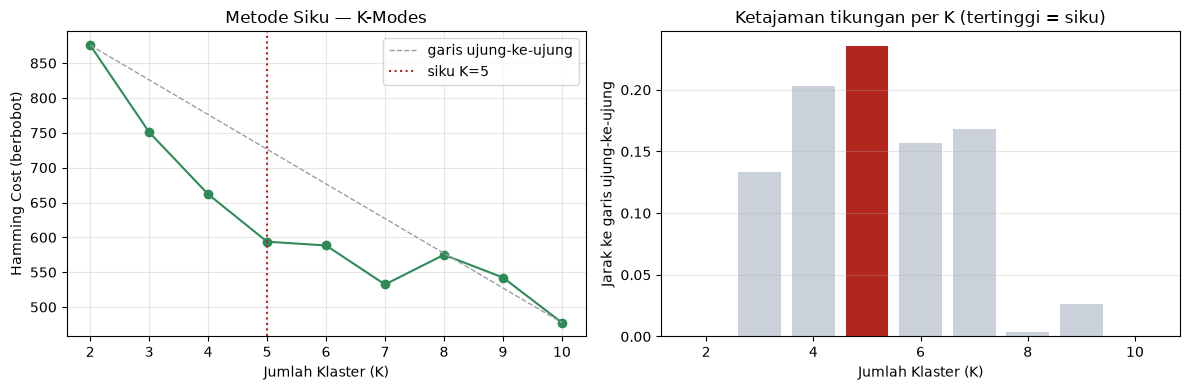

,K,Hamming Cost (berbobot),Penurunan,Jarak ke garis,Titik siku
0,2,875.7574,NaN,0.0000,
1,3,750.9113,124.8461,0.1334,
2,4,661.8703,89.0410,0.2031,
3,5,593.8148,68.0555,0.2356,<-- K dipilih
4,6,588.3939,5.4209,0.1569,
5,7,532.3837,56.0102,0.1680,
6,8,574.9726,-42.5888,0.0039,
7,9,542.3841,32.5884,0.0266,
8,10,477.6511,64.7330,0.0000,


K ditetapkan Metode Siku : 5
Total Hamming Cost polos : 1463.0
K notebook == K aplikasi : 5


,Titik awal diadu,Kurva menurun mulus,Siku
0,6,False,7
1,11,False,5
2,26,True,5
3,41,False,5


Sejak 11 titik awal (jumlah yang dipakai aplikasi), siku tidak berpindah lagi:
K = 5 pada seluruh konfigurasi di atasnya, walau kurvanya bergelombang.
Dengan 6 titik awal siku masih mendarat di K = 7 --
pencariannya belum mantap, dan justru itulah alasan aplikasi mengadu lebih banyak.


In [9]:
D_latihan = R.categorical_pairwise_distances(nilai_latihan)

# Kurva biaya yang SAMA dengan yang dipakai aplikasi menetapkan K.
kurva_latihan = R.exercise_cost_curve(kategori_latihan)
K_LATIHAN = [baris[0] for baris in kurva_latihan]
biaya_latihan = [baris[1] for baris in kurva_latihan]
K_SIKU_LATIHAN = R.elbow_cluster_count(K_LATIHAN, biaya_latihan)
jarak_latihan = R.elbow_distances(K_LATIHAN, biaya_latihan)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_LATIHAN, biaya_latihan, marker="o", color="seagreen")
ax1.plot([K_LATIHAN[0], K_LATIHAN[-1]], [biaya_latihan[0], biaya_latihan[-1]], "--",
         color="#9aa0a6", linewidth=1, label="garis ujung-ke-ujung")
ax1.axvline(K_SIKU_LATIHAN, color="#b3261e", linestyle=":", label=f"siku K={K_SIKU_LATIHAN}")
ax1.set(xlabel="Jumlah Klaster (K)", ylabel="Hamming Cost (berbobot)",
        title="Metode Siku — K-Modes")
ax1.legend(); ax1.grid(alpha=.3)

ax2.bar(K_LATIHAN, jarak_latihan,
        color=["#b3261e" if k == K_SIKU_LATIHAN else "#cbd1d9" for k in K_LATIHAN])
ax2.set(xlabel="Jumlah Klaster (K)", ylabel="Jarak ke garis ujung-ke-ujung",
        title="Ketajaman tikungan per K (tertinggi = siku)")
ax2.grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()

display(R.elbow_table(K_LATIHAN, biaya_latihan, cost_label="Hamming Cost (berbobot)"))

K_KMODES, label_kmodes, modes_kmodes = R.search_exercise_clusters(kategori_latihan)
exercises = exercises.assign(Klaster_KModes=label_kmodes)
cost_kmodes = R.kmodes_total_cost(nilai_latihan, label_kmodes, modes_kmodes)   # Hamming polos

print(f"K ditetapkan Metode Siku : {K_KMODES}")
print(f"Total Hamming Cost polos : {cost_kmodes:.1f}")

assert K_KMODES == K_SIKU_LATIHAN, "K aplikasi bukan titik siku kurva biaya"
assert K_KMODES == exercises["Exercise_Cluster"].nunique(), "K notebook != K yang dipakai aplikasi"
print("K notebook == K aplikasi :", exercises["Exercise_Cluster"].nunique())

# Apakah letak siku bergantung pada banyaknya titik awal yang diadu?
bobot_latihan = R.categorical_attribute_weights(nilai_latihan)
uji_siku = []
for percobaan in (5, 10, 25, 40):
    biaya = []
    for k in K_RANGE:
        terbaik = None
        for seed in [None, *range(percobaan)]:
            label, modes = R.fit_kmodes(kategori_latihan, n_clusters=k, random_state=seed)
            if len(np.unique(label)) < 2:
                continue
            nilai = R.kmodes_total_cost(nilai_latihan, label, modes, weights=bobot_latihan)
            if terbaik is None or nilai < terbaik:
                terbaik = nilai
        biaya.append(terbaik)
    uji_siku.append({
        "Titik awal diadu": percobaan + 1,
        "Kurva menurun mulus": all(biaya[i] < biaya[i - 1] for i in range(1, len(biaya))),
        "Siku": R.elbow_cluster_count(K_RANGE, biaya),
    })
display(pd.DataFrame(uji_siku))

DIPAKAI_APLIKASI = R.EXERCISE_INIT_ATTEMPTS + 1
siku_mantap = {b["Siku"] for b in uji_siku if b["Titik awal diadu"] >= DIPAKAI_APLIKASI}
siku_sedikit = [b for b in uji_siku if b["Titik awal diadu"] < DIPAKAI_APLIKASI]

print(f"Sejak {DIPAKAI_APLIKASI} titik awal (jumlah yang dipakai aplikasi), siku tidak berpindah lagi:")
print(f"K = {sorted(siku_mantap)[0]} pada seluruh konfigurasi di atasnya, walau kurvanya bergelombang.")
for b in siku_sedikit:
    print(f"Dengan {b['Titik awal diadu']} titik awal siku masih mendarat di K = {b['Siku']} --")
    print("pencariannya belum mantap, dan justru itulah alasan aplikasi mengadu lebih banyak.")

assert len(siku_mantap) == 1, f"siku masih berpindah di atas {DIPAKAI_APLIKASI} titik awal: {siku_mantap}"
assert K_KMODES in siku_mantap, "K aplikasi tidak sama dengan siku yang sudah mantap"

### 2.3 Perbandingan sebelum dan sesudah perbaikan

Kedua perbaikan (pembobotan atribut dan penambahan titik awal) diuji dengan **Rasio Hamming
polos tanpa bobot** — penggaris yang tidak ikut berubah saat cara melatihnya diubah. Tanpa
penguncian itu, setiap "perbaikan" bisa jadi hanya penggaris yang mengkerut.

K pada tiap konfigurasi ditetapkan dengan cara yang sama: Metode Siku atas fungsi biaya
konfigurasi itu sendiri.

In [10]:
satuan = np.ones(nilai_latihan.shape[1])


def evaluasi_kmodes(bobot_latih, percobaan):
    """Tetapkan K dengan Metode Siku untuk satu konfigurasi, lalu ukur Rasio Hamming polosnya.

    `bobot_latih=satuan` berarti melatih dengan Hamming polos; None berarti memakai
    bobot penyeimbang. Biaya yang dipakai mencari siku selalu biaya yang memang
    diminimalkan konfigurasi itu, supaya sikunya tidak dinilai dengan ukuran asing.
    """
    bobot_biaya = satuan if bobot_latih is not None else R.categorical_attribute_weights(nilai_latihan)
    biaya, label_per_k = [], {}
    for k in K_RANGE:
        terbaik = None
        for seed in [None, *range(percobaan)]:
            label, modes = R.fit_kmodes(kategori_latihan, n_clusters=k,
                                        random_state=seed, weights=bobot_latih)
            if len(np.unique(label)) < 2:
                continue
            nilai = R.kmodes_total_cost(nilai_latihan, label, modes, weights=bobot_biaya)
            if terbaik is None or nilai < terbaik[0]:
                terbaik = (nilai, label)
        biaya.append(terbaik[0])
        label_per_k[k] = terbaik[1]

    k_siku = R.elbow_cluster_count(K_RANGE, biaya)
    return R.hamming_separation_ratio(D_latihan, label_per_k[k_siku]), k_siku


perbandingan = []
for nama, bobot_uji, percobaan in [
    ("Hamming polos, 1 titik awal (kondisi awal)", satuan, 0),
    ("Hamming polos, 11 titik awal", satuan, 10),
    ("Bobot penyeimbang, 1 titik awal", None, 0),
    ("Bobot penyeimbang, 11 titik awal (dipakai aplikasi)", None, 10),
]:
    rasio, k = evaluasi_kmodes(bobot_uji, percobaan)
    perbandingan.append({"Konfigurasi": nama, "K (siku)": k, "Rasio Hamming": round(rasio, 4)})

tabel_banding = pd.DataFrame(perbandingan)
awal = tabel_banding.loc[0, "Rasio Hamming"]
tabel_banding["Perubahan"] = [f"{(r - awal) / awal:+.1%}" for r in tabel_banding["Rasio Hamming"]]
display(tabel_banding)
print("Dibandingkan pada K yang sama-sama ditetapkan Metode Siku, bukan pada K yang dipilih")
print("supaya angkanya terlihat bagus.")

,Konfigurasi,K (siku),Rasio Hamming,Perubahan
0,"Hamming polos, 1 titik awal (kondisi awal)",5,0.7164,+0.0%
1,"Hamming polos, 11 titik awal",5,0.7188,+0.3%
2,"Bobot penyeimbang, 1 titik awal",5,0.6802,-5.1%
3,"Bobot penyeimbang, 11 titik awal (dipakai apli...",5,0.6356,-11.3%


Dibandingkan pada K yang sama-sama ditetapkan Metode Siku, bukan pada K yang dipilih
supaya angkanya terlihat bagus.


### 2.4 Uji performa: Hamming Distance

Mutu klaster kategorikal dinyatakan **murni dalam Hamming distance**. Alasannya: ukuran
geometris mengandaikan adanya "jarak sebagian", padahal antara `Barbell` dan `Dumbbell` tidak
ada nilai tengah — yang ada hanya sama atau tidak sama.

Ukuran yang jujur untuk tipe data ini membandingkan dua rata-rata jarak Hamming:

$$d_H(x, y) = \sum_{j=1}^{p} \delta(x_j, y_j), \qquad
\delta(a,b) = \begin{cases} 0 & a = b \\ 1 & a \neq b \end{cases}$$

$$\text{Rasio} = \frac{\overline{d_H}\ \text{dalam klaster}}{\overline{d_H}\ \text{antar klaster}}$$

Rasio jauh di bawah 1 berarti anggota satu klaster memang jauh lebih mirip satu sama lain
daripada dengan anggota klaster lain. Itulah definisi klaster yang baik untuk data
kategorikal.

Angka ini dihitung **atas K yang sudah ditetapkan Metode Siku**, dan tidak ikut memilih K.
Konsekuensinya harus disebut: K yang lebih besar hampir selalu memberi Rasio Hamming yang
lebih kecil (klaster yang lebih sempit otomatis lebih seragam), jadi rasio pada K siku wajar
saja lebih tinggi daripada rasio pada K terbesar. Yang dinilai di sini adalah mutu pemisahan
pada jumlah klaster yang memang dipilih, bukan lomba mencari rasio terkecil.

### 2.5 Chi-Square Test — apakah pemisahannya signifikan?

Hamming distance menunjukkan seberapa mirip anggotanya. Chi-Square membuktikan bahwa
perbedaan antar-klaster itu **nyata secara statistik**, bukan kebetulan.

$$\chi^2 = \sum \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

$H_0$: atribut tidak bergantung pada klaster. Menolak $H_0$ (p < 0,05) berarti klasternya
benar-benar memisahkan karakteristik latihan.

,Ukuran,Nilai,Arti
0,Rata-rata Hamming DALAM klaster,1.4432,dari maksimum 4 atribut
1,Rata-rata Hamming ANTAR klaster,2.2708,dari maksimum 4 atribut
2,Rasio (dalam / antar),0.6356,Pemisahan lemah
3,Total Hamming Cost,1463.0000,total ketidakcocokan seluruh anggota ke modus ...


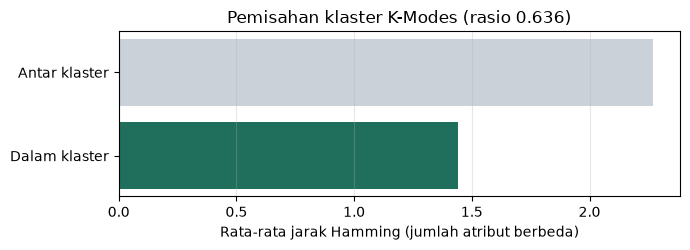

,Atribut,Chi-Square,dof,p-value,Kesimpulan
0,Type,1075.493,24,8.013137e-212,"Signifikan (p<0,05)"
1,BodyPart,1206.773,60,4.619267e-213,"Signifikan (p<0,05)"
2,Equipment,1913.503,44,0.000000e+00,"Signifikan (p<0,05)"
3,Level,1369.405,8,2.332104e-290,"Signifikan (p<0,05)"


Seluruh atribut signifikan (p < 0,05): True

Modus tiap klaster:


,Type,BodyPart,Equipment,Level,Jumlah
0,Strength,Quadriceps,Cable,Intermediate,481
1,Plyometrics,Quadriceps,Body Only,Intermediate,78
2,Strength,Abdominals,Body Only,Intermediate,393
3,Strength,Chest,Body Only,Beginner,105
4,Strength,Shoulders,Dumbbell,Intermediate,302



Contoh crosstab (BodyPart):


BodyPart,Abdominals,Abductors,Adductors,Biceps,Calves,Chest,Forearms,Glutes,Hamstrings,Lats,Lower Back,Middle Back,Quadriceps,Shoulders,Traps,Triceps
row_0,,,,,,,,,,,,,,,,
0,21,2,1,42,16,56,9,8,26,36,22,35,120,17,12,58
1,6,1,4,0,1,1,0,3,6,4,3,1,40,8,0,0
2,244,4,1,2,2,28,0,16,1,10,7,0,55,9,0,14
3,12,1,1,21,4,30,4,1,13,10,5,2,0,1,0,0
4,12,0,0,36,3,34,3,1,1,9,5,11,27,139,5,16


In [11]:
hamming = CM.hamming_separation(nilai_latihan, label_kmodes)
rasio_hamming = hamming["ratio"]

display(pd.DataFrame([
    {"Ukuran": "Rata-rata Hamming DALAM klaster", "Nilai": round(hamming["within_cluster"], 4),
     "Arti": f"dari maksimum {hamming['attributes']} atribut"},
    {"Ukuran": "Rata-rata Hamming ANTAR klaster", "Nilai": round(hamming["between_cluster"], 4),
     "Arti": f"dari maksimum {hamming['attributes']} atribut"},
    {"Ukuran": "Rasio (dalam / antar)", "Nilai": round(rasio_hamming, 4),
     "Arti": CM.interpret_hamming_ratio(rasio_hamming)},
    {"Ukuran": "Total Hamming Cost", "Nilai": round(cost_kmodes, 1),
     "Arti": "total ketidakcocokan seluruh anggota ke modus klasternya"},
]))

fig, ax = plt.subplots(figsize=(7, 2.6))
ax.barh(["Dalam klaster", "Antar klaster"],
        [hamming["within_cluster"], hamming["between_cluster"]],
        color=["#1f6f5c", "#cbd1d9"])
ax.set(xlabel="Rata-rata jarak Hamming (jumlah atribut berbeda)",
       title=f"Pemisahan klaster K-Modes (rasio {rasio_hamming:.3f})")
ax.grid(alpha=.3, axis="x"); plt.tight_layout(); plt.show()

# Fungsi yang sama dipakai halaman Admin aplikasi.
chi2_latihan = R.chi_square_report(kategori_latihan, label_kmodes)
display(chi2_latihan)

signifikan = (chi2_latihan["p-value"] < 0.05).all()
print("Seluruh atribut signifikan (p < 0,05):", signifikan)
print("\nModus tiap klaster:")
display(pd.DataFrame(modes_kmodes, columns=kategori_latihan.columns)
        .assign(Jumlah=pd.Series(label_kmodes).value_counts().sort_index().values))
print("\nContoh crosstab (BodyPart):")
display(pd.crosstab(label_kmodes, kategori_latihan["BodyPart"]))

### 2.6 Isi tiap klaster: apa yang sebenarnya dipisahkan?

Modus hanya menyebut nilai yang paling sering muncul; ia tidak memberi tahu **seberapa
dominan** nilai itu di dalam klasternya. Dua klaster bisa punya modus `Strength` yang sama
padahal yang satu 99% Strength dan yang lain hanya 60%.

Dua tabel di bawah menjawabnya. Tabel pertama menampilkan kategori terbanyak beserta
porsinya untuk tiap atribut. Tabel kedua mengukur **peran tiap atribut dalam membentuk
klaster**, dengan membandingkan kemurnian di dalam klaster terhadap sebaran atribut itu di
seluruh dataset:

- kenaikan besar → atribut itu ikut membentuk klaster;
- kenaikan mendekati nol → atribut itu tersebar merata di semua klaster, jadi praktis tidak
  memisahkan apa pun.

In [12]:
# --- Kategori terbanyak tiap atribut, per klaster ---------------------------- #
isi_klaster_latihan = []
for klaster, anggota in exercises.groupby("Klaster_KModes"):
    catatan = {
        "Klaster": int(klaster),
        "Jumlah": len(anggota),
        "% dataset": round(len(anggota) / len(exercises) * 100, 1),
    }
    for kolom in kategori_latihan.columns:
        teratas = anggota[kolom].value_counts()
        catatan[kolom] = f"{teratas.index[0]} ({teratas.iloc[0] / len(anggota):.0%})"
    catatan["Contoh gerakan"] = anggota["Title"].iloc[0][:32]
    isi_klaster_latihan.append(catatan)

print("Isi tiap klaster latihan (kategori terbanyak beserta porsinya):")
display(pd.DataFrame(isi_klaster_latihan))

# --- Atribut mana yang benar-benar memisahkan? ------------------------------- #
# Kemurnian dalam klaster dibandingkan dengan sebaran atribut di seluruh dataset.
ukuran_klaster = exercises.groupby("Klaster_KModes").size()
peran_atribut = []
for kolom in kategori_latihan.columns:
    sebaran_global = exercises[kolom].value_counts(normalize=True).iloc[0]
    per_klaster = [
        anggota[kolom].value_counts(normalize=True).iloc[0]
        for _, anggota in exercises.groupby("Klaster_KModes")
    ]
    kemurnian = float(np.average(per_klaster, weights=ukuran_klaster))
    peran_atribut.append({
        "Atribut": kolom,
        "Kategori dominan di seluruh dataset": f"{sebaran_global:.0%}",
        "Kemurnian rata-rata di dalam klaster": f"{kemurnian:.0%}",
        "Kenaikan": f"{kemurnian - sebaran_global:+.0%}",
        "Bobot penyeimbang": round(float(bobot[list(kategori_latihan.columns).index(kolom)]), 3),
    })

print("\nPeran tiap atribut dalam membentuk klaster:")
display(pd.DataFrame(peran_atribut))
print("Atribut yang bobot penyeimbangnya besar (karena isinya nyaris seragam) justru")
print("menunjukkan kenaikan kemurnian terbesar -- pembobotan di bagian 2.1 berhasil membuat")
print("atribut yang tadinya menumpang ikut memisahkan klaster.")

Isi tiap klaster latihan (kategori terbanyak beserta porsinya):


,Klaster,Jumlah,% dataset,Type,BodyPart,Equipment,Level,Contoh gerakan
0,0,481,35.4,Strength (94%),Quadriceps (25%),Cable (29%),Intermediate (99%),Standing cable low-to-high twist
1,1,78,5.7,Plyometrics (62%),Quadriceps (51%),Body Only (78%),Intermediate (97%),Sledgehammer swing
2,2,393,28.9,Strength (99%),Abdominals (62%),Body Only (80%),Intermediate (100%),Partner plank band row
3,3,105,7.7,Strength (84%),Chest (29%),Body Only (29%),Beginner (100%),Bench barbell roll-out
4,4,302,22.2,Strength (99%),Shoulders (46%),Dumbbell (76%),Intermediate (100%),Dumbbell V-Sit Cross Jab



Peran tiap atribut dalam membentuk klaster:


,Atribut,Kategori dominan di seluruh dataset,Kemurnian rata-rata di dalam klaster,Kenaikan,Bobot penyeimbang
0,Type,90%,94%,+4%,1.549
1,BodyPart,22%,42%,+20%,0.320
2,Equipment,30%,57%,+27%,0.335
3,Level,92%,99%,+8%,1.795


Atribut yang bobot penyeimbangnya besar (karena isinya nyaris seragam) justru
menunjukkan kenaikan kemurnian terbesar -- pembobotan di bagian 2.1 berhasil membuat
atribut yang tadinya menumpang ikut memisahkan klaster.


---
## 3. K-Prototypes — Profil Anggota (data campuran)

Numerik: `Age`, `Weight (kg)`, `Height (m)`, `BMI`.
Kategorikal: `Gender`, `Activity_Level`, `Experience_Label`, `Fitness_Goal`.

`Experience_Label` adalah hasil normalisasi kolom `Experience_Level` yang di dataset berisi
angka 1/2/3 menjadi Beginner/Intermediate/Expert — persis seperti yang dilakukan aplikasi,
supaya modus klaster terbaca sebagai label, bukan angka.

### Jarak pembentuk klaster

$$d(x, \mu) = \sum_{j \in \text{num}} (x_j - \mu_j)^2 \;+\; \gamma \sum_{j \in \text{cat}} \delta(x_j, \mu_j),
\qquad \gamma = 1$$

Nilai $\gamma = 1$ bukan angka sembarangan. Diuji pada $\gamma \in \{0{,}2;\ 0{,}5;\ 1;\ 2;\ 4\}$
dengan penilaian di ruang jarak tetap, hasilnya **jenuh**: $\gamma \geq 1$ memberi pemisahan
yang identik, sedangkan menurunkannya ke 0,2 justru merusaknya. Artinya struktur kelompok
pada data anggota memang terletak pada atribut kategorikal, dan memaksa ukuran tubuh lebih
berperan menurunkan mutu klaster.

Perlu dicatat bahwa BMI masuk lewat **dua jalur**: sebagai angka numerik, dan sebagai dasar
`Fitness_Goal` yang diturunkan darinya (BMI ≥ 25 → *Lose Weight*). Karena itu ukuran tubuh
tetap berperan kuat walaupun porsi numeriknya kecil.

### 3.1 Penetapan K: Metode Siku atas Fungsi Biaya

$$\text{Total Cost}(K) = \sum_{i=1}^{n} d(x_i, \mu_{c(i)})$$

Untuk tiap K = 2..10, **21 titik awal** (linspace + 20 seed tetap) diadu dan yang biayanya
terendah disimpan. Titik siku kurva biaya itulah K yang dipakai — dihitung, bukan ditaksir.

### 3.2 Uji performa: Silhouette Score dengan Gower Distance

Setelah K terbentuk, mutunya diuji dengan **Silhouette Score**, tetapi **bukan** di atas
jarak pembentuk klaster di atas. Jarak itu tidak berskala terbatas dan bagian numeriknya
berpangkat dua, sehingga nilai Silhouette yang dihasilkannya tidak sebanding dengan angka
Silhouette mana pun di literatur.

Yang dipakai adalah **Gower Distance**, jarak baku untuk data campuran, yang membatasi
sumbangan setiap atribut ke rentang 0..1:

$$d_{Gower}(i, j) = \frac{1}{p}\left[\sum_{a \in \text{num}} \frac{|x_{ia} - x_{ja}|}{R_a}
\;+\; \sum_{a \in \text{cat}} \delta(x_{ia}, x_{ja})\right]$$

dengan $R_a$ = rentang (maks − min) atribut numerik $a$, dan $p$ = jumlah seluruh atribut.

**Urutan perhitungannya:**

1. Bentuk **matriks jarak seluruh data** dengan formula Gower di atas → `matriks_gower`
   ($n \times n$).
2. Masukkan matriks itu ke `silhouette_score(matriks_gower, label_klaster, metric='precomputed')`.

$$S(i) = \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}}$$

dengan $a(i)$ = rata-rata jarak Gower ke sesama anggota klaster, $b(i)$ = rata-rata jarak
Gower ke anggota klaster tetangga terdekat. Nilainya −1 sampai 1; mendekati 1 berarti klaster
rapat dan terpisah.

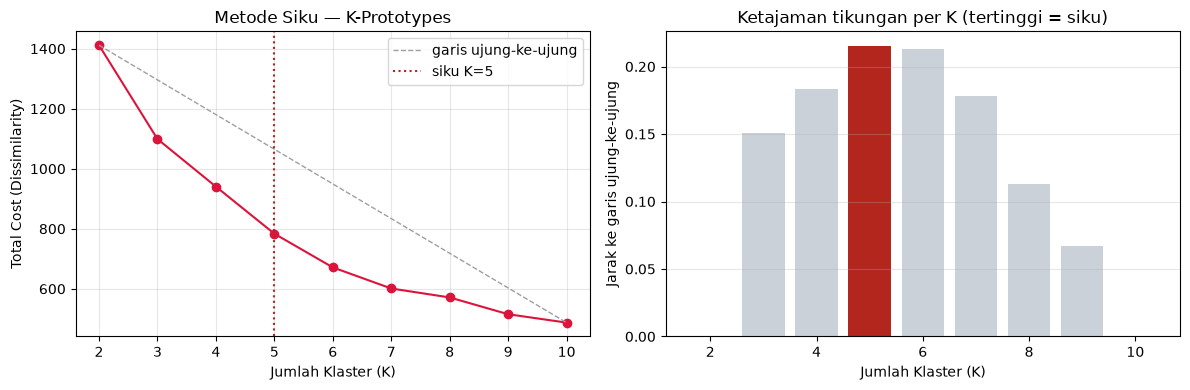

,K,Total Cost (Dissimilarity),Penurunan,Jarak ke garis,Titik siku
0,2,1411.5906,NaN,0.0000,
1,3,1099.0194,312.5711,0.1508,
2,4,940.4748,158.5446,0.1837,
3,5,783.6074,156.8674,0.2153,<-- K dipilih
4,6,671.3736,112.2338,0.2128,
5,7,601.0716,70.3020,0.1782,
6,8,571.2616,29.8100,0.1126,
7,9,515.3859,55.8757,0.0670,
8,10,487.3833,28.0026,0.0000,


K ditetapkan Metode Siku   : 5
Total Cost (Dissimilarity) : 783.61
K notebook == K aplikasi   : 5

Matriks Gower : 973 x 973, nilai 0.000 .. 0.863 (selalu di rentang 0..1)
Silhouette Score (Gower Distance) : 0.3311


Sama dengan yang dipakai aplikasi : True


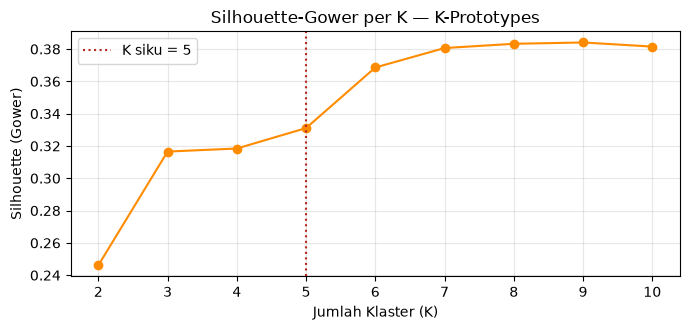

,K,Total Cost (Dissimilarity),Silhouette (Gower)
0,2,1411.59,0.2461
1,3,1099.02,0.3165
2,4,940.47,0.3184
3,5,783.61,0.3311
4,6,671.37,0.3686
5,7,601.07,0.3806
6,8,571.26,0.3832
7,9,515.39,0.3841
8,10,487.38,0.3815


In [13]:
# --- Penetapan K: Metode Siku atas Fungsi Biaya ------------------------------ #
kurva_anggota = R.member_cost_curve(numerik, kategorikal)
K_ANGGOTA = [baris[0] for baris in kurva_anggota]
biaya_anggota = [baris[1] for baris in kurva_anggota]
K_SIKU_ANGGOTA = R.elbow_cluster_count(K_ANGGOTA, biaya_anggota)
jarak_anggota = R.elbow_distances(K_ANGGOTA, biaya_anggota)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_ANGGOTA, biaya_anggota, marker="o", color="crimson")
ax1.plot([K_ANGGOTA[0], K_ANGGOTA[-1]], [biaya_anggota[0], biaya_anggota[-1]], "--",
         color="#9aa0a6", linewidth=1, label="garis ujung-ke-ujung")
ax1.axvline(K_SIKU_ANGGOTA, color="#b3261e", linestyle=":", label=f"siku K={K_SIKU_ANGGOTA}")
ax1.set(xlabel="Jumlah Klaster (K)", ylabel="Total Cost (Dissimilarity)",
        title="Metode Siku — K-Prototypes")
ax1.legend(); ax1.grid(alpha=.3)

ax2.bar(K_ANGGOTA, jarak_anggota,
        color=["#b3261e" if k == K_SIKU_ANGGOTA else "#cbd1d9" for k in K_ANGGOTA])
ax2.set(xlabel="Jumlah Klaster (K)", ylabel="Jarak ke garis ujung-ke-ujung",
        title="Ketajaman tikungan per K (tertinggi = siku)")
ax2.grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()

display(R.elbow_table(K_ANGGOTA, biaya_anggota, cost_label="Total Cost (Dissimilarity)"))

K_KPROTO, label_kproto, nm_final, cm_final = R.search_member_clusters(numerik, kategorikal)
cost_kproto = R.kprototypes_total_cost(numerik, kategorikal, label_kproto, nm_final, cm_final)

assert K_KPROTO == K_SIKU_ANGGOTA, "K aplikasi bukan titik siku kurva biaya"
assert K_KPROTO == members["User_Cluster"].nunique(), "K notebook != K yang dipakai aplikasi"
print(f"K ditetapkan Metode Siku   : {K_KPROTO}")
print(f"Total Cost (Dissimilarity) : {cost_kproto:.2f}")
print(f"K notebook == K aplikasi   : {members['User_Cluster'].nunique()}")

# --- Uji performa: Silhouette Score dengan Gower Distance --------------------- #
# Langkah 1: bentuk matriks jarak SELURUH data dengan formula Gower.
matriks_gower = R.gower_pairwise_distances(numerik, kategorikal)
print(f"\nMatriks Gower : {matriks_gower.shape[0]} x {matriks_gower.shape[1]}, "
      f"nilai {matriks_gower.min():.3f} .. {matriks_gower.max():.3f} (selalu di rentang 0..1)")

# Langkah 2: masukkan matriks itu ke silhouette_score sebagai jarak siap pakai.
sil_gower = silhouette_score(matriks_gower, label_kproto, metric="precomputed")
print(f"Silhouette Score (Gower Distance) : {sil_gower:.4f}")

# Nilai yang sama lewat pembungkus aplikasi -- membuktikan angka yang dilaporkan
# notebook adalah angka yang ditampilkan halaman Admin.
print("Sama dengan yang dipakai aplikasi :",
      np.isclose(sil_gower, R.gower_silhouette(numerik, kategorikal, label_kproto)))

# Silhouette-Gower pada seluruh rentang K, sebagai KETERANGAN -- bukan pemilih K.
sil_per_k = [
    silhouette_score(matriks_gower, baris[2], metric="precomputed")
    if len(np.unique(baris[2])) > 1 else np.nan
    for baris in kurva_anggota
]
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(K_ANGGOTA, sil_per_k, marker="o", color="darkorange")
ax.axvline(K_KPROTO, color="#b3261e", linestyle=":", label=f"K siku = {K_KPROTO}")
ax.set(xlabel="Jumlah Klaster (K)", ylabel="Silhouette (Gower)",
       title="Silhouette-Gower per K — K-Prototypes")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

display(pd.DataFrame({"K": K_ANGGOTA,
                      "Total Cost (Dissimilarity)": np.round(biaya_anggota, 2),
                      "Silhouette (Gower)": np.round(sil_per_k, 4)}))

### 3.3 Profil klaster dan konsistensi penempatan pengguna

Dua hal diperiksa di sini:

1. **Profil domain** — rata-rata numerik dan modus kategorikal tiap klaster harus masuk akal.
2. **Konsistensi penempatan** — `assign_user_cluster` menempatkan pengguna baru ke klaster.
   Fungsi itu wajib memakai rumus jarak yang sama dengan yang membentuk klasternya, jika tidak
   pengguna bisa mendarat di klaster yang bukan terdekat. Diuji dengan memasukkan ulang seluruh
   anggota dataset dan membandingkan hasilnya dengan label pelatihan mereka.

In [14]:
profil_num = members.groupby("User_Cluster")[KOL_NUM].mean().round(1)
profil_kat = members.groupby("User_Cluster")[KOL_KAT].agg(lambda s: s.mode().iloc[0])
jumlah = members.groupby("User_Cluster").size().rename("Jumlah_Anggota")
display(profil_num.join(profil_kat).join(jumlah))

cocok = 0
for _, baris in members.iterrows():
    tinggi_cm = baris["Height (m)"] * 100 if baris["Height (m)"] < 3 else baris["Height (m)"]
    profil = {
        "age": baris["Age"], "weight_kg": baris["Weight (kg)"], "height_cm": tinggi_cm,
        "bmi": baris["BMI"], "gender": baris["Gender"],
        "activity_level": baris["Activity_Level"],
        "experience_level": baris["Experience_Label"],
        "fitness_goal": baris["Fitness_Goal"],
    }
    cocok += R.assign_user_cluster(members, profil) == int(baris["User_Cluster"])

akurasi_penempatan = cocok / len(members)
print(f"Penempatan sama dengan label pelatihan: {cocok}/{len(members)} = {akurasi_penempatan:.2%}")
assert akurasi_penempatan == 1.0, "assign_user_cluster tidak konsisten dengan model!"

,Age,Weight (kg),Height (m),BMI,Gender,Activity_Level,Experience_Label,Fitness_Goal,Jumlah_Anggota
User_Cluster,,,,,,,,,
1,38.2,74.0,1.7,24.4,Male,Very High,Expert,Maintain Weight,182
2,35.0,62.3,1.6,23.4,Female,High,Intermediate,Lose Weight,194
3,37.5,90.3,1.8,28.8,Male,High,Intermediate,Lose Weight,214
4,41.2,81.5,1.8,25.2,Male,Medium,Beginner,Lose Weight,185
5,41.6,60.1,1.6,22.5,Female,Medium,Beginner,Lose Weight,198


Penempatan sama dengan label pelatihan: 973/973 = 100.00%


### 3.4 Isi tiap klaster: atribut mana yang membentuknya?

Profil di atas menampilkan rata-rata numerik dan modus kategorikal. Sama seperti pada
K-Modes, angka itu belum memberi tahu seberapa murni tiap klaster, dan yang lebih penting:
**atribut mana yang sebenarnya membentuk pembagian ini.**

Untuk atribut **kategorikal**, ukurannya sama dengan bagian 2.6 — kemurnian di dalam klaster
dibandingkan sebaran globalnya. Kenaikan besar berarti atribut itu ikut membentuk klaster.

Untuk atribut **numerik**, ukurannya dibalik: berapa **porsi rentang global** yang masih
dicakup sebuah klaster. Kalau satu klaster masih membentang di seluruh rentang usia dataset,
artinya usia tidak memisahkan siapa pun — anggota berusia sama tersebar di semua klaster.
Makin kecil porsinya, makin tegas atribut itu memisahkan:

| Porsi rentang yang masih dicakup | Penilaian |
|---|---|
| ≥ 80% | Nyaris tidak memisahkan |
| 50–80% | Memisahkan lemah |
| < 50% | Ikut memisahkan |

Hasil kedua tabel ini menjadi bukti angka untuk pernyataan γ = 1 di awal bab ini, bahwa
struktur kelompok pada data anggota terletak pada atribut kategorikal.

In [15]:
# --- Kemurnian kategorikal dan rentang numerik, per klaster ------------------ #
isi_klaster_anggota = []
for klaster, anggota in members.groupby("User_Cluster"):
    catatan = {"Klaster": int(klaster), "Jumlah": len(anggota)}
    for kolom in KOL_KAT:
        teratas = anggota[kolom].value_counts()
        catatan[kolom] = f"{teratas.index[0]} ({teratas.iloc[0] / len(anggota):.0%})"
    catatan["Rentang BMI"] = f"{anggota['BMI'].min():.1f} - {anggota['BMI'].max():.1f}"
    catatan["Rentang usia"] = f"{anggota['Age'].min():.0f} - {anggota['Age'].max():.0f}"
    isi_klaster_anggota.append(catatan)

print("Isi tiap klaster anggota (kategori terbanyak, porsinya, dan rentang numeriknya):")
display(pd.DataFrame(isi_klaster_anggota))

# --- Atribut kategorikal: seberapa murni di dalam klaster? ------------------- #
ukuran_anggota = members.groupby("User_Cluster").size()
kenaikan_kategorikal = {}
peran_kategorikal = []
for kolom in KOL_KAT:
    sebaran_global = members[kolom].value_counts(normalize=True).iloc[0]
    per_klaster = [
        anggota[kolom].value_counts(normalize=True).iloc[0]
        for _, anggota in members.groupby("User_Cluster")
    ]
    kemurnian = float(np.average(per_klaster, weights=ukuran_anggota))
    kenaikan_kategorikal[kolom] = kemurnian - sebaran_global
    peran_kategorikal.append({
        "Atribut kategorikal": kolom,
        "Kategori dominan di seluruh dataset": f"{sebaran_global:.0%}",
        "Kemurnian rata-rata di dalam klaster": f"{kemurnian:.0%}",
        "Kenaikan": f"{kemurnian - sebaran_global:+.0%}",
    })
print("\nPeran atribut KATEGORIKAL (makin besar kenaikannya, makin membentuk klaster):")
display(pd.DataFrame(peran_kategorikal))

# --- Atribut numerik: berapa banyak rentang global yang masih dicakup? ------- #
def nilai_pemisahan(porsi):
    """Terjemahkan porsi rentang yang masih dicakup jadi kalimat penilaian."""
    if porsi >= 0.80:
        return "Nyaris tidak memisahkan"
    if porsi >= 0.50:
        return "Memisahkan lemah"
    return "Ikut memisahkan"


porsi_numerik = {}
peran_numerik = []
for kolom in KOL_NUM:
    rentang_global = float(members[kolom].max() - members[kolom].min())
    rentang_klaster = members.groupby("User_Cluster")[kolom].agg(lambda s: s.max() - s.min())
    porsi = float(np.average(rentang_klaster, weights=ukuran_anggota)) / rentang_global
    porsi_numerik[kolom] = porsi
    peran_numerik.append({
        "Atribut numerik": kolom,
        "Rentang seluruh dataset": f"{members[kolom].min():.1f} - {members[kolom].max():.1f}",
        "Porsi rentang yang masih dicakup satu klaster": f"{porsi:.0%}",
        "Penilaian": nilai_pemisahan(porsi),
    })
print("\nPeran atribut NUMERIK (makin mendekati 100%, makin tidak memisahkan):")
display(pd.DataFrame(peran_numerik))

# --- Kesimpulan dihitung dari kedua tabel di atas ---------------------------- #
tanpa_peran = [k for k, p in porsi_numerik.items() if p >= 0.80]
tegas = [k for k, p in porsi_numerik.items() if p < 0.50]
kat_terkuat = max(kenaikan_kategorikal, key=kenaikan_kategorikal.get)
porsi_terkecil = min(porsi_numerik.values())
porsi_terbesar = max(porsi_numerik.values())

print(f"\nAtribut kategorikal terkuat : {kat_terkuat} "
      f"(kenaikan kemurnian {kenaikan_kategorikal[kat_terkuat]:+.0%}); seluruh atribut")
print(f"                              kategorikal naik {min(kenaikan_kategorikal.values()):+.0%} "
      f"sampai {max(kenaikan_kategorikal.values()):+.0%}.")
print(f"Atribut numerik             : tiap klaster masih mencakup "
      f"{porsi_terkecil:.0%}-{porsi_terbesar:.0%} rentang dataset.")
if tanpa_peran:
    print(f"Tidak memisahkan sama sekali: {', '.join(tanpa_peran)} "
          f"(satu klaster membentang di seluruh rentangnya).")
print(f"Memisahkan dengan tegas     : {', '.join(tegas) if tegas else 'tidak ada'}.")
print("\nJadi pembagian klaster dibentuk atribut kategorikal; atribut numerik hanya")
print("mempersempit, tidak memisahkan. Itu sekaligus alasan Silhouette-Gower bernilai sedang:")
print("Gower memberi bobot setara pada kedelapan atribut, dan separuhnya tidak menyumbang")
print("pemisahan yang tegas.")

assert not tegas or all(kenaikan_kategorikal[k] > 0 for k in kenaikan_kategorikal), \
    "kesimpulan tidak lagi sesuai dengan angkanya -- tinjau ulang bagian 3.4"

Isi tiap klaster anggota (kategori terbanyak, porsinya, dan rentang numeriknya):


,Klaster,Jumlah,Gender,Activity_Level,Experience_Label,Fitness_Goal,Rentang BMI,Rentang usia
0,1,182,Male (62%),Very High (94%),Expert (94%),Maintain Weight (62%),17.2 - 34.5,18 - 59
1,2,194,Female (100%),High (81%),Intermediate (87%),Lose Weight (79%),12.5 - 34.1,18 - 59
2,3,214,Male (100%),High (93%),Intermediate (86%),Lose Weight (74%),12.3 - 49.8,18 - 59
3,4,185,Male (100%),Medium (88%),Beginner (86%),Lose Weight (58%),12.7 - 47.7,18 - 59
4,5,198,Female (100%),Medium (85%),Beginner (82%),Lose Weight (82%),12.7 - 35.0,18 - 59



Peran atribut KATEGORIKAL (makin besar kenaikannya, makin membentuk klaster):


,Atribut kategorikal,Kategori dominan di seluruh dataset,Kemurnian rata-rata di dalam klaster,Kenaikan
0,Gender,53%,93%,+40%
1,Activity_Level,41%,88%,+47%
2,Experience_Label,42%,87%,+45%
3,Fitness_Goal,66%,71%,+6%



Peran atribut NUMERIK (makin mendekati 100%, makin tidak memisahkan):


,Atribut numerik,Rentang seluruh dataset,Porsi rentang yang masih dicakup satu klaster,Penilaian
0,Age,18.0 - 59.0,100%,Nyaris tidak memisahkan
1,Weight (kg),40.0 - 129.9,64%,Memisahkan lemah
2,Height (m),1.5 - 2.0,76%,Memisahkan lemah
3,BMI,12.3 - 49.8,72%,Memisahkan lemah



Atribut kategorikal terkuat : Activity_Level (kenaikan kemurnian +47%); seluruh atribut
                              kategorikal naik +6% sampai +47%.
Atribut numerik             : tiap klaster masih mencakup 64%-100% rentang dataset.
Tidak memisahkan sama sekali: Age (satu klaster membentang di seluruh rentangnya).
Memisahkan dengan tegas     : tidak ada.

Jadi pembagian klaster dibentuk atribut kategorikal; atribut numerik hanya
mempersempit, tidak memisahkan. Itu sekaligus alasan Silhouette-Gower bernilai sedang:
Gower memberi bobot setara pada kedelapan atribut, dan separuhnya tidak menyumbang
pemisahan yang tegas.


---
## 4. Uji Stabilitas — apakah hasilnya berubah kalau dijalankan ulang?

Nilai metrik yang bagus tidak berarti apa-apa kalau berubah setiap kali algoritma dijalankan.
Bagian ini menjalankan **setiap algoritma 50 kali dengan inisialisasi acak berbeda**, lalu
menghitung **varians** nilai biaya dan metrik mutunya.

Perlu satu catatan penting supaya hasilnya tidak salah dibaca:

> **Aplikasi berjalan tanpa keacakan sama sekali.** Untuk tiap K, `search_exercise_clusters`
> dan `search_member_clusters` mengadu sekumpulan titik awal yang SELALU sama — inisialisasi
> `np.linspace` ditambah seed tetap 0..N−1 — lalu mengambil yang biayanya terendah. Tidak ada
> yang diundi saat aplikasi berjalan, sehingga hasilnya **dijamin** sama persis setiap kali
> dijalankan. Varians di produksi adalah nol.

Uji di bawah sengaja **memasukkan keacakan** lewat parameter `random_state`, yang menjalankan
algoritma dari **satu** titik awal saja. Pertanyaan yang dijawabnya berbeda: seberapa peka
algoritma ini terhadap titik awal seandainya hanya dicoba sekali?

Jawabannya sekaligus menjadi **pembenaran rancangan**. Kalau sebaran 50 eksekusi itu lebar,
maka menjalankan sekali saja memang berisiko mendarat di solusi buruk — dan itulah alasan
aplikasi mengadu banyak titik awal alih-alih percaya pada satu tebakan. Nilai yang dipakai
aplikasi bisa dibandingkan langsung terhadap sebaran ini: ia berada di ujung terbaiknya.

Ukuran yang dipakai adalah **koefisien variasi** (simpangan baku ÷ rata-rata), karena
membandingkan varians Silhouette (skala 0–1) dengan varians Cost (skala ratusan) secara
langsung tidak bermakna. Di bawah 1%, perbedaan antar-eksekusi tidak akan mengubah satu pun
angka yang dilaporkan pada dua desimal.

In [16]:
JUMLAH_EKSEKUSI = 50

# --- K-Means: sklearn menerima random_state, jadi cukup diganti seed-nya ---
def kmeans_ch(seed):
    label = KMeans(n_clusters=R.FOOD_CLUSTER_COUNT, init="k-means++",
                   n_init=10, random_state=seed).fit_predict(X_makanan)
    return calinski_harabasz_score(X_makanan, label)

def kmeans_inertia(seed):
    return KMeans(n_clusters=R.FOOD_CLUSTER_COUNT, init="k-means++",
                  n_init=10, random_state=seed).fit(X_makanan).inertia_

# --- K-Modes: random_state mengacak pilihan modus awal ---
def kmodes_cost(seed):
    label, modes = R.fit_kmodes(kategori_latihan, n_clusters=K_KMODES, random_state=seed)
    return R.kmodes_total_cost(nilai_latihan, label, modes)

def kmodes_rasio(seed):
    label, _ = R.fit_kmodes(kategori_latihan, n_clusters=K_KMODES, random_state=seed)
    return CM.hamming_separation(nilai_latihan, label)["ratio"]

# --- K-Prototypes: random_state mengacak pilihan prototipe awal ---
def kproto_cost(seed):
    label, nm, cm = R.fit_kprototypes(numerik, kategorikal, n_clusters=K_KPROTO, random_state=seed)
    return R.kprototypes_total_cost(numerik, kategorikal, label, nm, cm)

def kproto_silhouette_gower(seed):
    label, _, _ = R.fit_kprototypes(numerik, kategorikal, n_clusters=K_KPROTO, random_state=seed)
    if len(np.unique(label)) < 2:
        return 0.0
    return float(silhouette_score(matriks_gower, label, metric="precomputed"))

hasil_stabilitas = [
    CM.stability_over_runs(kmeans_ch,       runs=JUMLAH_EKSEKUSI, metric="K-Means — Calinski-Harabasz"),
    CM.stability_over_runs(kmeans_inertia,  runs=JUMLAH_EKSEKUSI, metric="K-Means — Inertia"),
    CM.stability_over_runs(kmodes_cost,     runs=JUMLAH_EKSEKUSI, metric="K-Modes — Total Hamming Cost"),
    CM.stability_over_runs(kmodes_rasio,    runs=JUMLAH_EKSEKUSI, metric="K-Modes — Rasio Hamming"),
    CM.stability_over_runs(kproto_cost,     runs=JUMLAH_EKSEKUSI, metric="K-Prototypes — Total Cost"),
    CM.stability_over_runs(kproto_silhouette_gower, runs=JUMLAH_EKSEKUSI,
                           metric="K-Prototypes — Silhouette (Gower)"),
]

tabel_stabilitas = CM.stability_table(hasil_stabilitas)
display(tabel_stabilitas)

semua_konsisten = all(r.is_stable for r in hasil_stabilitas)
print(f"Seluruh metrik konsisten pada {JUMLAH_EKSEKUSI} eksekusi:", semua_konsisten)

,Metrik,Eksekusi,Rata-rata,Varians,Simpangan baku,Minimum,Maksimum,Koef. variasi,Kesimpulan
0,K-Means — Calinski-Harabasz,50,709.0003,0.005309,0.072866,708.9059,709.0919,0.0103%,Konsisten
1,K-Means — Inertia,50,48.5462,0.000010,0.003174,48.5423,48.5504,0.0065%,Konsisten
2,K-Modes — Total Hamming Cost,50,1548.5800,11952.166939,109.325966,1368.0000,1895.0000,7.0598%,Berubah antar-eksekusi
3,K-Modes — Rasio Hamming,50,0.7267,0.003039,0.055128,0.6261,0.8508,7.5859%,Berubah antar-eksekusi
4,K-Prototypes — Total Cost,50,932.6091,14889.241147,122.021478,783.6107,1397.8443,13.0839%,Berubah antar-eksekusi
5,K-Prototypes — Silhouette (Gower),50,0.2752,0.002279,0.047738,0.1574,0.3430,17.3492%,Berubah antar-eksekusi


Seluruh metrik konsisten pada 50 eksekusi: False


### 4.1 Sebaran nilai antar-eksekusi

Kotak (boxplot) di bawah menunjukkan seberapa lebar nilainya berayun. Kotak yang tampak
sebagai satu garis berarti seluruh eksekusi mendarat di nilai yang sama.

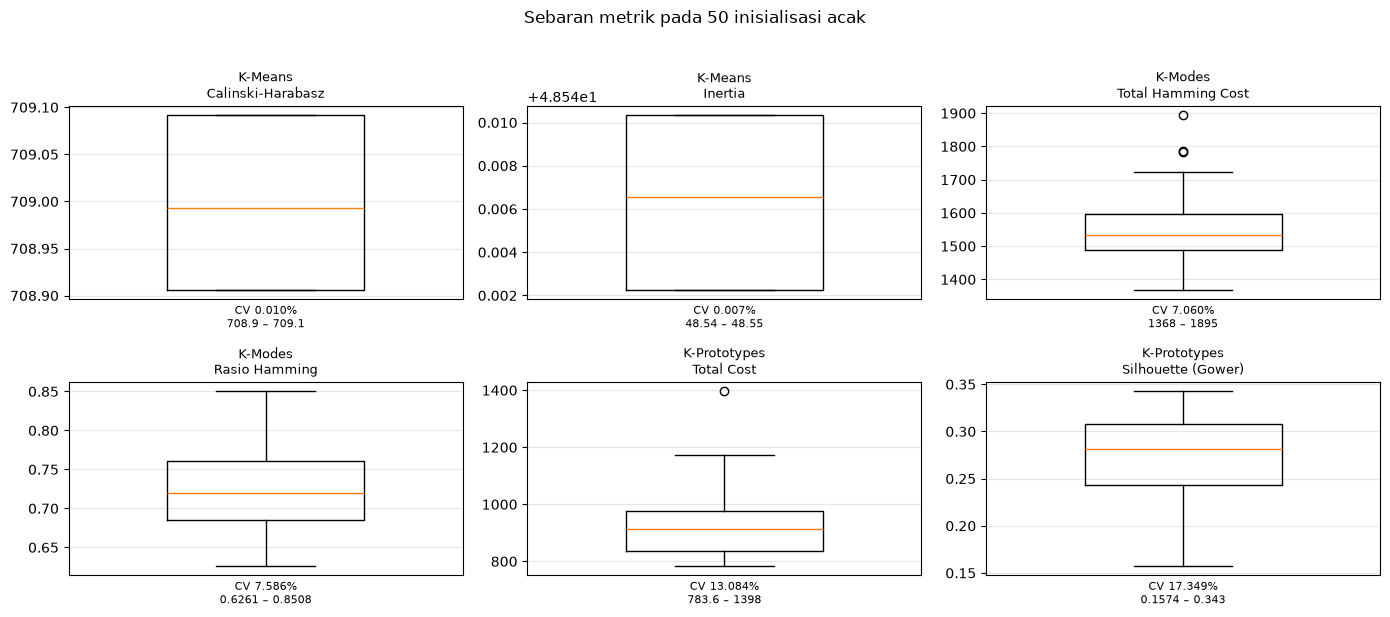

Kesimpulan per metrik:
  KONSISTEN  K-Means — Calinski-Harabasz                  varians=0.00530941  CV=0.0103%
  KONSISTEN  K-Means — Inertia                            varians=1.00738e-05  CV=0.0065%
  BERUBAH    K-Modes — Total Hamming Cost                 varians=11952.2  CV=7.0598%
  BERUBAH    K-Modes — Rasio Hamming                      varians=0.0030391  CV=7.5859%
  BERUBAH    K-Prototypes — Total Cost                    varians=14889.2  CV=13.0839%
  BERUBAH    K-Prototypes — Silhouette (Gower)            varians=0.00227891  CV=17.3492%


In [17]:
fig, sumbu = plt.subplots(2, 3, figsize=(14, 6))
for ax, r in zip(sumbu.ravel(), hasil_stabilitas):
    ax.boxplot(r.values, widths=0.5)          # vertikal = bawaan matplotlib
    ax.set_title(r.metric.replace(" — ", chr(10)), fontsize=9)
    ax.set_xticks([])
    ax.grid(alpha=.3, axis="y")
    rendah, tinggi = r.spread
    ax.set_xlabel(f"CV {r.coefficient_of_variation:.3%}" + chr(10) + f"{rendah:.4g} – {tinggi:.4g}", fontsize=8)
plt.suptitle(f"Sebaran metrik pada {JUMLAH_EKSEKUSI} inisialisasi acak", y=1.02)
plt.tight_layout(); plt.show()

print("Kesimpulan per metrik:")
for r in hasil_stabilitas:
    status = "KONSISTEN" if r.is_stable else "BERUBAH"
    print(f"  {status:10s} {r.metric:44s} varians={r.variance:.6g}  CV={r.coefficient_of_variation:.4%}")

### 4.2 Di mana letak nilai yang dipakai aplikasi?

Sebaran yang lebar pada K-Modes dan K-Prototypes bukan kelemahan aplikasi — justru itulah
alasan aplikasi tidak pernah puas dengan satu titik awal. Pertanyaan yang menentukan adalah:
**dari seluruh 50 kemungkinan itu, di posisi mana nilai yang benar-benar dipakai berada?**

In [18]:
posisi = []
for r, nilai_aplikasi, lebih_baik_kecil in [
    (hasil_stabilitas[2], cost_kmodes,      True),    # K-Modes Total Hamming Cost
    (hasil_stabilitas[3], hamming["ratio"], True),    # K-Modes Rasio Hamming
    (hasil_stabilitas[4], cost_kproto,      True),    # K-Prototypes Total Cost
    (hasil_stabilitas[5], sil_gower,        False),   # K-Prototypes Silhouette (Gower)
]:
    nilai = np.asarray(r.values, dtype=float)
    kalah = int((nilai < nilai_aplikasi).sum() if lebih_baik_kecil else (nilai > nilai_aplikasi).sum())
    rendah, tinggi = float(nilai.min()), float(nilai.max())
    posisi.append({
        "Metrik": r.metric,
        "Nilai aplikasi": round(float(nilai_aplikasi), 4),
        "Rata-rata 50 acak": round(float(nilai.mean()), 4),
        "Terbaik dari 50": round(rendah if lebih_baik_kecil else tinggi, 4),
        "Eksekusi acak yang mengalahkan": f"{kalah} dari {r.runs}",
    })
display(pd.DataFrame(posisi))
print("Nol berarti tidak satu pun dari 50 inisialisasi acak menghasilkan solusi lebih baik")
print("daripada yang dipilih aplikasi. Nilai yang dilaporkan bukan hasil satu tebakan beruntung,")
print("melainkan yang terbaik dari seluruh ruang inisialisasi yang diperiksa.")

,Metrik,Nilai aplikasi,Rata-rata 50 acak,Terbaik dari 50,Eksekusi acak yang mengalahkan
0,K-Modes — Total Hamming Cost,1463.0000,1548.5800,1368.0000,9 dari 50
1,K-Modes — Rasio Hamming,0.6356,0.7267,0.6261,2 dari 50
2,K-Prototypes — Total Cost,783.6074,932.6091,783.6107,0 dari 50
3,K-Prototypes — Silhouette (Gower),0.3311,0.2752,0.3430,6 dari 50


Nol berarti tidak satu pun dari 50 inisialisasi acak menghasilkan solusi lebih baik
daripada yang dipilih aplikasi. Nilai yang dilaporkan bukan hasil satu tebakan beruntung,
melainkan yang terbaik dari seluruh ruang inisialisasi yang diperiksa.


---
## 5. Content-Based Filtering + TF-IDF

### Metrik yang dipakai: berbasis peringkat (Top-N)

Keluaran CBF bukan satu jawaban benar/salah, melainkan **daftar terurut**. Metrik yang tepat
untuk bentuk itu adalah metrik berbasis peringkat, dan dua yang dipakai di sini adalah
**MAP** dan **NDCG**.

**MAP (Mean Average Precision).** Presisi diukur ulang setiap kali item relevan ditemukan,
lalu dirata-ratakan. Item relevan yang muncul lebih awal menyumbang lebih besar, dan seluruh
item relevan di dalam Top-K ikut dihitung:

$$AP@K = \frac{1}{\min(R, K)} \sum_{i=1}^{K} P@i \cdot rel_i
\qquad\qquad
MAP@K = \frac{1}{|Q|}\sum_{q \in Q} AP@K(q)$$

dengan $rel_i = 1$ bila item pada peringkat $i$ relevan, $P@i$ = presisi pada peringkat $i$,
dan $R$ = jumlah item relevan yang tersedia. Pembaginya $\min(R,K)$ supaya kueri dengan item
relevan lebih sedikit daripada K tetap bisa mencapai 1,0 pada susunan sempurna.

**NDCG (Normalized Discounted Cumulative Gain).** Sumbangan tiap item relevan diredam
logaritma peringkatnya, lalu dibagi susunan sempurna:

$$DCG@K = \sum_{i=1}^{K} \frac{rel_i}{\log_2(i+1)}
\qquad
IDCG@K = \sum_{i=1}^{\min(R,K)} \frac{1}{\log_2(i+1)}
\qquad
NDCG@K = \frac{DCG@K}{IDCG@K}$$

Karena dinormalkan, kueri berisi 5 item relevan dan kueri berisi 200 item relevan bisa
dirata-ratakan tanpa yang satu menenggelamkan yang lain.

Keduanya memakai relevansi **biner** — sebuah item relevan atau tidak — karena itulah bentuk
kebenaran yang tersedia: sebuah menu berkategori "Ayam" tidak lebih atau kurang berkategori
Ayam daripada menu ayam lainnya. Implementasinya ada di `src/ranking_metrics.py`.

### 5.1 CBF menu makanan

Bentuk pengujian mengikuti aplikasi: **kueri → item**, bukan item → item. Aplikasi tidak
menghitung kemiripan antar-menu; preferensi pengguna diubah jadi vektor TF-IDF lalu
dicocokkan dengan seluruh menu.

- **Korpus** — kolom `CBF_Text` bentukan aplikasi: nama + kalori + protein + lemak +
  karbohidrat + klaster + kategori.
- **Vectorizer** — `TfidfVectorizer(stop_words="english")`, sama dengan aplikasi.
- **Kueri** — dirakit `R.build_preference_query`, fungsi yang sama yang dipakai aplikasi.
- **Ground truth relevansi** — **kategori bahan utama** (`Food_Category`) hasil
  `primary_food_category`. Sebuah menu relevan terhadap kueri "Ayam" bila kategorinya memang
  Ayam. Ini label yang bermakna dan bisa diperiksa manusia, bukan label acak.

Yang diukur di sini adalah **peringkat TF-IDF murni** atas seluruh korpus. Aplikasi masih
menambah pencocokan kategori sebagai kunci urutan pertama sebelum skor cosine dipakai, jadi
daftar yang benar-benar dilihat pengguna sama baik atau lebih baik daripada angka di bawah.

In [19]:
vectorizer = TfidfVectorizer(stop_words="english")
tfidf = vectorizer.fit_transform(foods["CBF_Text"])
print("Ukuran matriks TF-IDF menu:", tfidf.shape)

kategori_uji = [k for k in R.available_food_categories(foods) if k != R.OTHER_CATEGORY]
print(f"Kueri diuji: {len(kategori_uji)} kategori bahan utama\n")


def peringkat_menu(label_kategori):
    """Seluruh menu, terurut dari cosine similarity tertinggi terhadap satu kueri kategori."""
    kueri = R.build_preference_query("", [label_kategori])
    skor = cosine_similarity(vectorizer.transform([kueri]), tfidf).ravel()
    return np.argsort(-skor, kind="stable"), skor


K_EVAL = (5, 10)
relevansi_menu = {}
for label_kategori in kategori_uji:
    urutan, _ = peringkat_menu(label_kategori)
    relevansi_menu[label_kategori] = foods["Food_Category"].to_numpy()[urutan] == label_kategori

display(RM.ranking_report(relevansi_menu, K_EVAL))

map_menu = {k: RM.mean_average_precision(relevansi_menu.values(), k) for k in K_EVAL}
ndcg_menu = {k: RM.mean_ndcg(relevansi_menu.values(), k) for k in K_EVAL}
for k in K_EVAL:
    print(f"MAP@{k:<3}= {map_menu[k]:.4f}      NDCG@{k:<3}= {ndcg_menu[k]:.4f}")

Ukuran matriks TF-IDF menu: (814, 1134)


Kueri diuji: 15 kategori bahan utama



,Kueri,Item relevan,AP@5,NDCG@5,AP@10,NDCG@10
0,Ayam,23,1.0,1.0,1.00,1.0000
1,Ikan & Seafood,91,1.0,1.0,1.00,1.0000
2,Daging Sapi,20,1.0,1.0,1.00,1.0000
3,Daging Kambing,1,1.0,1.0,1.00,1.0000
4,Telur,20,1.0,1.0,1.00,1.0000
5,"Tahu, Tempe & Oncom",44,1.0,1.0,1.00,1.0000
6,Sayuran,67,1.0,1.0,1.00,1.0000
7,Kacang-kacangan,40,1.0,1.0,1.00,1.0000
8,Nasi & Olahan Beras,33,1.0,1.0,1.00,1.0000
9,Mie & Bihun,16,1.0,1.0,1.00,1.0000


MAP@5  = 1.0000      NDCG@5  = 1.0000
MAP@10 = 0.9853      NDCG@10 = 0.9910


### 5.2 CBF program latihan

Rekomendasi latihan memakai TF-IDF yang sama, tetapi tugas peringkatnya berbeda, dan
perbedaannya harus dijelaskan supaya angkanya tidak salah dibaca.

`recommend_exercises` bekerja dua tahap:

1. **Penyaringan keras** — hanya latihan yang levelnya diizinkan (`LEVEL_ALLOWLIST`) dan
   target ototnya cocok (`TARGET_MUSCLE_GROUPS`) yang masuk kolam kandidat.
2. **Perankingan TF-IDF** — kolam itu diurutkan menurut cosine similarity terhadap kueri
   `"{target otot} {jenis} {alat} {level}"`.

Karena itu **target otot dan level tidak bisa menjadi ground truth**: keduanya sudah dijamin
tahap pertama, dan menilainya lagi hanya akan menghasilkan angka sempurna yang tidak
membuktikan apa pun. Ada alasan kedua yang lebih teknis: label target otot pada kueri
berbahasa Indonesia ("Dada", "Punggung") sedangkan korpusnya berbahasa Inggris
("Chest", "Middle Back") — kata itu memang tidak bisa dicocokkan TF-IDF, dan justru
itulah sebabnya aplikasi menanganinya dengan penyaringan, bukan dengan peringkat.

Yang benar-benar diputuskan peringkat TF-IDF adalah **jenis latihan** dan **alat**. Maka:

- **Kolam** — hasil penyaringan level + target otot, persis seperti aplikasi.
- **Kueri** — string yang sama yang dirakit aplikasi.
- **Ground truth relevansi** — latihan relevan bila `Type` **dan** `Equipment`-nya sama
  dengan yang diminta kueri.
- Penyaringan `Type` sengaja **tidak** diterapkan di sini, supaya peringkatnya yang harus
  mengangkat jenis yang diminta ke atas — itulah yang sedang diuji.

In [20]:
LEVEL_UJI = "Beginner"
JENIS_UJI = ["Strength", "Cardio", "Stretching"]
ALAT_UJI = ["Barbell", "Dumbbell", "Body Only"]

relevansi_latihan = {}
for bagian in R.TARGET_MUSCLE_GROUPS:
    # Tahap 1 aplikasi: saring level + target otot.
    kolam = exercises[
        exercises["Level"].isin(R.LEVEL_ALLOWLIST[LEVEL_UJI])
        & exercises["BodyPart"].isin(R.resolve_target_body_parts(bagian))
    ]
    if kolam.empty:
        continue
    # Tahap 2 aplikasi: TF-IDF dilatih pada KOLAM, bukan pada seluruh korpus --
    # sama seperti recommend_exercises melakukannya.
    vec_latihan = TfidfVectorizer(stop_words="english")
    matriks_latihan = vec_latihan.fit_transform(kolam["CBF_Text"])

    for jenis in JENIS_UJI:
        for alat in ALAT_UJI:
            relevan = ((kolam["Type"] == jenis) & (kolam["Equipment"] == alat)).to_numpy()
            if not relevan.any():
                continue                      # kombinasi ini memang tidak ada di dataset
            kueri = f"{bagian} {jenis} {alat} {LEVEL_UJI}"
            skor = cosine_similarity(vec_latihan.transform([kueri]), matriks_latihan).ravel()
            urutan = np.argsort(-skor, kind="stable")
            relevansi_latihan[f"{bagian} / {jenis} / {alat}"] = relevan[urutan]

print(f"Kueri latihan diuji: {len(relevansi_latihan)} kombinasi target otot x jenis x alat\n")
display(RM.ranking_report(relevansi_latihan, K_EVAL).head(12))

map_latihan = {k: RM.mean_average_precision(relevansi_latihan.values(), k) for k in K_EVAL}
ndcg_latihan = {k: RM.mean_ndcg(relevansi_latihan.values(), k) for k in K_EVAL}
for k in K_EVAL:
    print(f"MAP@{k:<3}= {map_latihan[k]:.4f}      NDCG@{k:<3}= {ndcg_latihan[k]:.4f}")

Kueri latihan diuji: 16 kombinasi target otot x jenis x alat



,Kueri,Item relevan,AP@5,NDCG@5,AP@10,NDCG@10
0,Dada / Strength / Barbell,2,0.75,0.8772,0.7500,0.8772
1,Dada / Strength / Dumbbell,1,1.00,1.0000,1.0000,1.0000
2,Dada / Strength / Body Only,13,0.13,0.2773,0.2734,0.4526
3,Punggung / Strength / Barbell,1,1.00,1.0000,1.0000,1.0000
4,Punggung / Strength / Body Only,1,0.50,0.6309,0.5000,0.6309
5,Lengan / Strength / Barbell,8,0.76,0.8539,0.9068,0.9672
6,Lengan / Strength / Dumbbell,9,1.00,1.0000,0.8627,0.9217
7,Core/Inti/Perut / Strength / Barbell,1,1.00,1.0000,1.0000,1.0000
8,Core/Inti/Perut / Strength / Dumbbell,1,1.00,1.0000,1.0000,1.0000
9,Core/Inti/Perut / Strength / Body Only,7,1.00,1.0000,0.9325,0.9799


MAP@5  = 0.8473      NDCG@5  = 0.8881
MAP@10 = 0.8526      NDCG@10 = 0.9000


### 5.3 Pembanding: peringkat acak

Angka MAP dan NDCG tidak berarti apa-apa tanpa pembanding. Nilai 0,4 bisa bagus atau buruk
tergantung berapa banyak item relevan yang tersedia di korpus.

Pembanding di bawah **mengacak urutan penanda relevansi yang sama** sebanyak 200 kali. Karena
yang diacak adalah daftar yang persis sama, pembandingnya berbagi ukuran korpus dan proporsi
item relevan yang identik — selisihnya murni sumbangan TF-IDF, bukan efek perbedaan data.

,Dataset,K,MAP CBF,MAP acak,NDCG CBF,NDCG acak,Peningkatan MAP
0,Menu makanan,5,1.0000,0.0206,1.0000,0.0418,48.5x
1,Menu makanan,10,0.9853,0.0143,0.9910,0.0422,68.9x
2,Program latihan,5,0.8473,0.2095,0.8881,0.2889,4.0x
3,Program latihan,10,0.8526,0.2483,0.9000,0.3824,3.4x


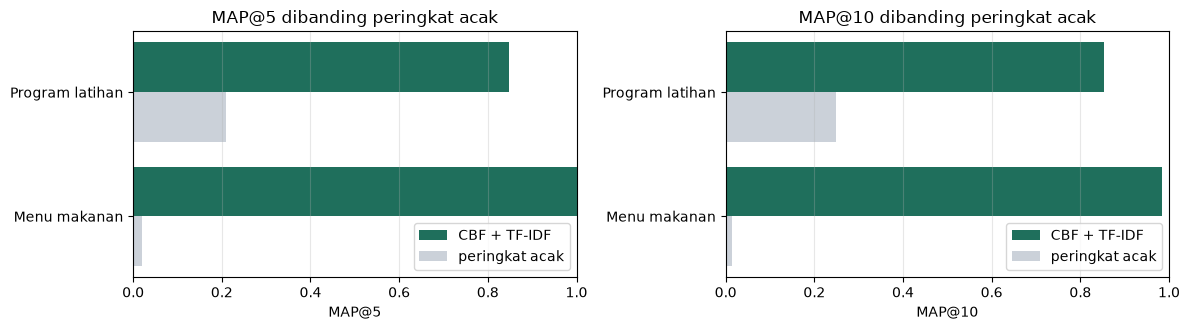

In [21]:
banding = []
for nama, relevansi, hasil_map, hasil_ndcg in [
    ("Menu makanan", relevansi_menu, map_menu, ndcg_menu),
    ("Program latihan", relevansi_latihan, map_latihan, ndcg_latihan),
]:
    acak = RM.random_baseline(relevansi, K_EVAL).set_index("K")
    for k in K_EVAL:
        banding.append({
            "Dataset": nama, "K": k,
            "MAP CBF": round(hasil_map[k], 4), "MAP acak": acak.loc[k, "MAP acak"],
            "NDCG CBF": round(hasil_ndcg[k], 4), "NDCG acak": acak.loc[k, "NDCG acak"],
            "Peningkatan MAP": (f"{hasil_map[k] / acak.loc[k, 'MAP acak']:.1f}x"
                                if acak.loc[k, "MAP acak"] else "-"),
        })
tabel_banding_cbf = pd.DataFrame(banding)
display(tabel_banding_cbf)

fig, sumbu = plt.subplots(1, 2, figsize=(12, 3.4))
for ax, k in zip(sumbu, K_EVAL):
    potong = tabel_banding_cbf[tabel_banding_cbf["K"] == k]
    posisi_y = np.arange(len(potong))
    ax.barh(posisi_y + 0.2, potong["MAP CBF"], height=0.4, color="#1f6f5c", label="CBF + TF-IDF")
    ax.barh(posisi_y - 0.2, potong["MAP acak"], height=0.4, color="#cbd1d9", label="peringkat acak")
    ax.set_yticks(posisi_y); ax.set_yticklabels(potong["Dataset"])
    ax.set(xlim=(0, 1), xlabel=f"MAP@{k}", title=f"MAP@{k} dibanding peringkat acak")
    ax.grid(alpha=.3, axis="x"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

### 5.4 Contoh keluaran rekomendasi

Bukti kualitatif: lima menu teratas untuk beberapa kueri kategori.

In [22]:
for label_kategori in ["Ayam", "Ikan & Seafood", "Sayuran"]:
    urutan, skor = peringkat_menu(label_kategori)
    atas = foods.iloc[urutan[:5]][["name", "Food_Category", "calories"]].copy()
    atas["skor"] = np.round(skor[urutan[:5]], 4)
    print(f"\nKueri: {label_kategori}")
    display(atas.reset_index(drop=True))


Kueri: Ayam


,name,Food_Category,calories,skor
0,soto ayam,Ayam,108.0,0.7032
1,Mie ayam,Ayam,102.0,0.6947
2,sayur sop ayam,Ayam,72.0,0.6944
3,bubur ayam,Ayam,159.0,0.6783
4,Pisang ayam segar,Ayam,120.0,0.6720



Kueri: Ikan & Seafood


,name,Food_Category,calories,skor
0,ikan asin kacangan,Ikan & Seafood,84.0,0.5814
1,ikan asin goreng,Ikan & Seafood,162.0,0.5552
2,Ikan Mas goreng,Ikan & Seafood,188.0,0.5325
3,ikan asin pari,Ikan & Seafood,84.0,0.5292
4,ikan asin selar,Ikan & Seafood,162.0,0.5285



Kueri: Sayuran


,name,Food_Category,calories,skor
0,Asinan Bogor sayuran,Sayuran,98.0,0.4987
1,sayur kangkung,Sayuran,11.0,0.3906
2,Sayur sop,Sayuran,27.0,0.3828
3,Wortel rebus,Sayuran,28.0,0.3649
4,sayur gambas,Sayuran,30.0,0.3554


---
## 6. Pengujian Fungsional

Klasterisasi dan CBF hanya sebagian dari sistem. Aturan bisnis yang membuat NutriFit berbeda
diuji oleh skrip di folder `tests/`, dan hasilnya dilampirkan di sini sebagai bagian dari bab
pengujian.

| Skrip | Yang dibuktikan |
|---|---|
| `test_recommender.py` | total kuota empat slot = kebutuhan energi harian; gramasi = (kuota ÷ kalori/100 g) × 100; Volumetric Sanity Check 50–450 g; slot camilan tidak pernah berisi makanan berat; Dynamic Portion Constraint pada tukar menu |
| `test_claims.py` | klaim menu & latihan menyesuaikan kalori dan makro hari itu; makro diskalakan ke gramasi porsi |
| `test_password.py` | Argon2id, salt acak, migrasi hash lama, penolakan kata sandi polos |
| `test_app_smoke.py` | seluruh halaman render tanpa error; tukar menu tidak mengubah total kalori |
| `test_legacy_records.py` | record lama dari versi sebelumnya tetap terbaca |

In [23]:
import subprocess

SKRIP = ["test_recommender.py", "test_claims.py", "test_password.py",
         "test_app_smoke.py", "test_legacy_records.py"]

hasil_fungsional = []
for nama in SKRIP:
    proses = subprocess.run([sys.executable, str(ROOT / "tests" / nama)],
                            capture_output=True, text=True, cwd=str(ROOT))
    lulus = proses.returncode == 0
    baris_akhir = [b for b in proses.stdout.strip().splitlines() if b.strip()]
    hasil_fungsional.append({
        "Skrip": nama,
        "Status": "LULUS" if lulus else "GAGAL",
        "Ringkasan": baris_akhir[-1][:70] if baris_akhir else proses.stderr.strip()[-70:],
    })

tabel_fungsional = pd.DataFrame(hasil_fungsional)
display(tabel_fungsional)
print("Seluruh pengujian fungsional lulus:",
      bool((tabel_fungsional["Status"] == "LULUS").all()))

,Skrip,Status,Ringkasan
0,test_recommender.py,LULUS,SEMUA ASSERT LOLOS
1,test_claims.py,LULUS,[isolasi] schema uji_claims dibuang
2,test_password.py,LULUS,[isolasi] schema uji_password dibuang
3,test_app_smoke.py,LULUS,[isolasi] schema uji_smoke dibuang
4,test_legacy_records.py,LULUS,[isolasi] schema uji_legacy dibuang


Seluruh pengujian fungsional lulus: True


---
## 7. Ringkasan Hasil Pengujian

Tabel berikut siap disalin sebagai Tabel Hasil Pengujian pada Bab IV.

In [24]:
ringkasan = pd.DataFrame([
    # ---------------------------------------------------------------- K-Means --
    {"Algoritma": "K-Means", "Data": f"Menu makanan ({len(foods)} baris)",
     "Pengujian": "Metode Siku (Elbow) atas WCSS",
     "Hasil": f"siku K={K_SIKU_MAKANAN}; dipakai K={R.FOOD_CLUSTER_COUNT}",
     "Interpretasi": "K dipatok 3 karena peran gizi A/B/C pada MEAL_TEMPLATE"},
    {"Algoritma": "K-Means", "Data": f"Menu makanan ({len(foods)} baris)",
     "Pengujian": "Calinski-Harabasz Index", "Hasil": round(ch_kmeans, 4),
     "Interpretasi": "Makin besar = klaster makin terpisah relatif terhadap sebarannya"},
    {"Algoritma": "K-Means", "Data": f"Menu makanan ({len(foods)} baris)",
     "Pengujian": "Silhouette Coefficient", "Hasil": round(sil_kmeans, 4),
     "Interpretasi": "-1 s.d. 1; puncaknya kebetulan di K=3, tapi tidak dipakai memilih K"},
    {"Algoritma": "K-Means", "Data": f"Menu makanan ({len(foods)} baris)",
     "Pengujian": "Inertia (WCSS)", "Hasil": round(inertia_kmeans, 4),
     "Interpretasi": "Mendekati 0 = anggota rapat ke pusat klasternya"},

    # ---------------------------------------------------------------- K-Modes --
    {"Algoritma": "K-Modes", "Data": f"Program latihan ({len(exercises)} baris)",
     "Pengujian": "Metode Siku (Elbow) atas Hamming Cost", "Hasil": f"K={K_KMODES}",
     "Interpretasi": "K ditetapkan dari titik siku kurva biaya, bukan dari metrik mutu"},
    {"Algoritma": "K-Modes", "Data": f"Program latihan ({len(exercises)} baris)",
     "Pengujian": "Hamming Distance (rasio dalam/antar)", "Hasil": round(rasio_hamming, 4),
     "Interpretasi": CM.interpret_hamming_ratio(rasio_hamming)},
    {"Algoritma": "K-Modes", "Data": f"Program latihan ({len(exercises)} baris)",
     "Pengujian": "Total Hamming Cost", "Hasil": round(cost_kmodes, 1),
     "Interpretasi": "Total ketidakcocokan anggota ke modus klasternya"},
    {"Algoritma": "K-Modes", "Data": f"Program latihan ({len(exercises)} baris)",
     "Pengujian": "Chi-Square (p-value maksimum)",
     "Hasil": float(chi2_latihan["p-value"].max()),
     "Interpretasi": "p < 0,05 pada SEMUA atribut = klaster signifikan"},

    # ----------------------------------------------------------- K-Prototypes --
    {"Algoritma": "K-Prototypes", "Data": f"Profil anggota ({len(members)} baris)",
     "Pengujian": "Metode Siku (Elbow) atas Cost Function", "Hasil": f"K={K_KPROTO}",
     "Interpretasi": "K ditetapkan dari titik siku kurva Total Cost"},
    {"Algoritma": "K-Prototypes", "Data": f"Profil anggota ({len(members)} baris)",
     "Pengujian": "Total Cost (Dissimilarity)", "Hasil": round(cost_kproto, 2),
     "Interpretasi": "Total jarak gabungan numerik + kategorikal ke prototipe"},
    {"Algoritma": "K-Prototypes", "Data": f"Profil anggota ({len(members)} baris)",
     "Pengujian": "Silhouette Score dengan Gower Distance", "Hasil": round(sil_gower, 4),
     "Interpretasi": "Mendekati 1 = klaster campuran rapat dan terpisah"},

    # ------------------------------------------------------------ CBF menu --
    {"Algoritma": "CBF + TF-IDF", "Data": f"Menu makanan ({len(foods)} baris)",
     "Pengujian": "MAP@5", "Hasil": round(map_menu[5], 4),
     "Interpretasi": "Presisi rata-rata seluruh item relevan di Top-5"},
    {"Algoritma": "CBF + TF-IDF", "Data": f"Menu makanan ({len(foods)} baris)",
     "Pengujian": "NDCG@5", "Hasil": round(ndcg_menu[5], 4),
     "Interpretasi": "Mutu urutan Top-5 terhadap susunan sempurna"},
    {"Algoritma": "CBF + TF-IDF", "Data": f"Menu makanan ({len(foods)} baris)",
     "Pengujian": "MAP@10", "Hasil": round(map_menu[10], 4),
     "Interpretasi": "Presisi rata-rata seluruh item relevan di Top-10"},
    {"Algoritma": "CBF + TF-IDF", "Data": f"Menu makanan ({len(foods)} baris)",
     "Pengujian": "NDCG@10", "Hasil": round(ndcg_menu[10], 4),
     "Interpretasi": "Mutu urutan Top-10 terhadap susunan sempurna"},

    # --------------------------------------------------------- CBF latihan --
    {"Algoritma": "CBF + TF-IDF", "Data": f"Program latihan ({len(relevansi_latihan)} kueri)",
     "Pengujian": "MAP@5", "Hasil": round(map_latihan[5], 4),
     "Interpretasi": "Ranking jenis + alat di dalam kolam hasil penyaringan"},
    {"Algoritma": "CBF + TF-IDF", "Data": f"Program latihan ({len(relevansi_latihan)} kueri)",
     "Pengujian": "NDCG@5", "Hasil": round(ndcg_latihan[5], 4),
     "Interpretasi": "Mutu urutan Top-5 terhadap susunan sempurna"},
    {"Algoritma": "CBF + TF-IDF", "Data": f"Program latihan ({len(relevansi_latihan)} kueri)",
     "Pengujian": "MAP@10", "Hasil": round(map_latihan[10], 4),
     "Interpretasi": "Ranking jenis + alat di dalam kolam hasil penyaringan"},
    {"Algoritma": "CBF + TF-IDF", "Data": f"Program latihan ({len(relevansi_latihan)} kueri)",
     "Pengujian": "NDCG@10", "Hasil": round(ndcg_latihan[10], 4),
     "Interpretasi": "Mutu urutan Top-10 terhadap susunan sempurna"},

    # -------------------------------------------------------------- Hopkins --
    {"Algoritma": "Semua", "Data": "Menu makanan",
     "Pengujian": "Hopkins Statistic", "Hasil": round(h_makanan, 4),
     "Interpretasi": CM.interpret_hopkins(h_makanan)},
    {"Algoritma": "Semua", "Data": "Program latihan",
     "Pengujian": "Hopkins Statistic", "Hasil": round(h_latihan, 4),
     "Interpretasi": CM.interpret_hopkins(h_latihan)},
    {"Algoritma": "Semua", "Data": "Profil anggota",
     "Pengujian": "Hopkins Statistic", "Hasil": round(h_anggota, 4),
     "Interpretasi": CM.interpret_hopkins(h_anggota)},
    {"Algoritma": "Semua", "Data": "Ketiga algoritma",
     "Pengujian": f"Stabilitas {JUMLAH_EKSEKUSI} eksekusi",
     "Hasil": "Konsisten" if semua_konsisten else "Ada yang berubah",
     "Interpretasi": "Varians metrik lintas inisialisasi acak"},
    {"Algoritma": "Aturan bisnis", "Data": "Seluruh sistem",
     "Pengujian": "Pengujian fungsional (5 skrip)",
     "Hasil": f"{int((tabel_fungsional['Status'] == 'LULUS').sum())}/{len(tabel_fungsional)} lulus",
     "Interpretasi": "Kuota slot, gramasi, camilan, klaim, keamanan"},
])
display(ringkasan)

print("\nJumlah klaster yang dipakai dan dasar penetapannya:")
display(pd.DataFrame([
    {"Algoritma": "K-Means (makanan)", "K": R.FOOD_CLUSTER_COUNT,
     "Dasar": f"Struktural (peran gizi A/B/C); siku WCSS di K={K_SIKU_MAKANAN}, "
              f"Silhouette memuncak di K={K_RANGE[int(np.argmax(sil_per_k_makanan))]}"},
    {"Algoritma": "K-Modes (latihan)", "K": K_KMODES,
     "Dasar": f"Metode Siku atas Hamming Cost dari {R.EXERCISE_INIT_ATTEMPTS + 1} titik awal"},
    {"Algoritma": "K-Prototypes (anggota)", "K": K_KPROTO,
     "Dasar": f"Metode Siku atas Total Cost dari {R.MEMBER_INIT_ATTEMPTS + 1} titik awal"},
]))

,Algoritma,Data,Pengujian,Hasil,Interpretasi
0,K-Means,Menu makanan (814 baris),Metode Siku (Elbow) atas WCSS,siku K=5; dipakai K=3,K dipatok 3 karena peran gizi A/B/C pada MEAL_...
1,K-Means,Menu makanan (814 baris),Calinski-Harabasz Index,708.9929,Makin besar = klaster makin terpisah relatif t...
2,K-Means,Menu makanan (814 baris),Silhouette Coefficient,0.4935,"-1 s.d. 1; puncaknya kebetulan di K=3, tapi ti..."
3,K-Means,Menu makanan (814 baris),Inertia (WCSS),48.5466,Mendekati 0 = anggota rapat ke pusat klasternya
4,K-Modes,Program latihan (1359 baris),Metode Siku (Elbow) atas Hamming Cost,K=5,"K ditetapkan dari titik siku kurva biaya, buka..."
5,K-Modes,Program latihan (1359 baris),Hamming Distance (rasio dalam/antar),0.6356,Pemisahan lemah
6,K-Modes,Program latihan (1359 baris),Total Hamming Cost,1463.0,Total ketidakcocokan anggota ke modus klasternya
7,K-Modes,Program latihan (1359 baris),Chi-Square (p-value maksimum),0.0,"p < 0,05 pada SEMUA atribut = klaster signifikan"
8,K-Prototypes,Profil anggota (973 baris),Metode Siku (Elbow) atas Cost Function,K=5,K ditetapkan dari titik siku kurva Total Cost
9,K-Prototypes,Profil anggota (973 baris),Total Cost (Dissimilarity),783.61,Total jarak gabungan numerik + kategorikal ke ...



Jumlah klaster yang dipakai dan dasar penetapannya:


,Algoritma,K,Dasar
0,K-Means (makanan),3,Struktural (peran gizi A/B/C); siku WCSS di K=...
1,K-Modes (latihan),5,Metode Siku atas Hamming Cost dari 11 titik awal
2,K-Prototypes (anggota),5,Metode Siku atas Total Cost dari 21 titik awal


---
## Referensi Istilah

| Istilah | Arti singkat |
|---|---|
| Metode Siku (Elbow Method) | Penetapan K dari titik kurva biaya yang paling jauh dari garis penghubung kedua ujungnya |
| WCSS / Inertia | Total jarak kuadrat tiap titik ke pusat klasternya (K-Means) |
| Calinski-Harabasz Index | Sebaran antar klaster ÷ sebaran dalam klaster; makin besar makin terpisah |
| Cost | Total *matching dissimilarity* ke modus klaster (K-Modes) |
| Total Cost / Dissimilarity | Jumlah jarak seluruh anggota ke prototipe klasternya (K-Prototypes) |
| Hamming Distance | Jumlah atribut yang berbeda antara dua baris kategorikal |
| Rasio Hamming | Rata-rata jarak dalam klaster ÷ antar klaster; makin kecil makin terpisah |
| Gower Distance | Jarak data campuran: selisih numerik dibagi rentangnya + ketidakcocokan kategori, dirata-ratakan; selalu 0–1 |
| Silhouette Score | −1 s.d. 1; seberapa mirip titik dengan klasternya dibanding klaster tetangga |
| Hopkins Statistic | Kelayakan data diklaster; →1 sangat berkelompok, ≈0,5 acak |
| Varians / Koef. variasi | Sebaran nilai metrik antar-eksekusi; kecil = hasilnya konsisten |
| Chi-Square | Uji kemandirian; p < 0,05 = sebaran atribut berbeda nyata antar-klaster |
| TF-IDF | Bobot kata: sering di satu dokumen, jarang di korpus |
| Cosine Similarity | Kemiripan arah dua vektor, 0 s.d. 1 |
| MAP@K | Rata-rata Average Precision: presisi diukur ulang tiap kali item relevan ditemukan di Top-K |
| NDCG@K | Keuntungan item relevan diredam log peringkatnya, dibagi susunan sempurna |

## Catatan Reproduksibilitas

- Seluruh angka dihitung dari **keluaran pipeline aplikasi**, bukan CSV mentah.
- K-Modes dan K-Prototypes memakai **implementasi aplikasi**, bukan library `kmodes`.
- K ditetapkan **Metode Siku** lewat fungsi yang sama yang dipanggil aplikasi saat berjalan
  (`R.search_exercise_clusters`, `R.search_member_clusters`), dan titik sikunya dihitung
  (`R.elbow_cluster_count`), bukan ditaksir dari grafik.
- Metrik mutu tidak pernah ikut memilih K. Calinski-Harabasz, Silhouette-Gower, dan Rasio
  Hamming seluruhnya dihitung sesudah K ditetapkan.
- `random_state=42` pada K-Means; K-Modes/K-Prototypes memakai inisialisasi deterministik,
  jadi hasilnya sama di setiap eksekusi tanpa perlu seed.
- Pembanding acak MAP/NDCG memakai `random_state=42` dengan 200 pengacakan.